# 11b · Self-selected ad exposure, on real data — the Criteo experiment (IV · CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**
> First run downloads the 311 MB Criteo file into `~/.cache/cmp` (one-time; a seeded subsample is
> cached after that).

**The business decision.** Notebook [11](11_endogenous_exposure_iv.ipynb)'s story, at industrial
scale and with nothing simulated: **13.98 million real users** from Criteo's advertising
incrementality tests (Diemert et al. 2018). Users who *saw* an ad visit the advertiser at hugely
elevated rates — but the ad system *chose* whom to show ads to (bids, browsing, auctions), so
exposure is **self-selected** and the naive comparison credits the ad with intent that was already
there. We want the true causal effect of exposure, to set the **budget cap per exposed user**.

### Why this dataset is a gift for IV

Criteo's incrementality tests randomize **eligibility**: a random 15% of users are locked out of
the campaign entirely. That randomized `treatment` flag is a textbook **encouragement instrument** — we randomize a *nudge*
toward exposure (eligibility), not exposure itself — for the self-selected `exposure`:

- **Relevance** — eligibility moves exposure (3.6% of eligible users end up exposed) — *testable*,
  first-stage F below;
- **Exclusion** — being *silently eligible* does nothing to your visiting behaviour unless an ad
  actually reaches you — *untestable*, stress-tested in Step 6;
- **Exogeneity** — eligibility is randomized by the test infrastructure — *holds by design*;
- **Monotonicity, for free**: ineligible users are **never** exposed (one-sided noncompliance), so
  "defiers" are impossible *by construction*, not by assumption — and the **LATE** (local average treatment effect —
  the effect for exactly the users the instrument moves) specializes to the **effect on the exposed**
  (ATT), exactly the population a budget cap is about.

### What replaces the simulator's planted truth

Two real-data anchors. **(a)** At n = 13.98M the design-based **Wald estimate** (intent-to-treat ÷
first stage) is essentially free of sampling noise — we compute it once on the full file and grade
every subsample estimate against it. **(b)** The features let us *photograph the confounding
itself*: f0–f11 are balanced across the randomized arms but sharply imbalanced across exposure —
the self-selection nb11 could only simulate, measured.

In [1]:
import os, warnings, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import data, estimators as est, plots
from cmp.cache import load_or_run   # fit once, load forever — a live lecture never waits on NUTS
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"
N_ARM = 15_000 if FAST else 100_000     # rows per randomized arm in the working subsample
N_FIT = 30_000 if FAST else 100_000     # rows the Bayesian IV actually fits (posterior cost ~ n)
COST = 0.20                              # assumed cost per exposed user (€) — swept in step 6
VALUE_PER_VISIT = 1.0                    # assumed value of one incremental visit (€) — swept in step 6
N_EXP_QUARTER = 1_000_000                # assumed exposures bought per quarter — scales step 6's cap gap to campaign euros
print(f"FAST={FAST}  subsample={2 * N_ARM:,} rows  Bayesian fit on {N_FIT:,} rows")

FAST=False  subsample=200,000 rows  Bayesian fit on 100,000 rows


## 2 · Load the real data (what replaces "simulate a ground truth")

`cmp.data.load_criteo_uplift()` downloads the full file once, then caches a **seeded, balanced
subsample** — `N_ARM` rows from each randomized arm. Balancing the 85/15 arms is legitimate
*because* the sampling key is the randomized flag itself (both the ITT and the first stage are
conditional on `treatment`, so selecting on it biases nothing) and roughly doubles precision per
row. The one estimator the balancing *does* shift is the naive as-treated gap, whose unexposed
pool mixes the two arms — the load cell prices that shift, and §5 returns to it. The **data card**:

| fact | value |
|---|---|
| population | 13,979,592 users, assembled from several incrementality tests |
| randomization | `treatment` = eligible to be targeted (85%) vs locked out (15%) |
| self-selection | `exposure` = actually saw an ad: **3.6% of eligible, 0.0% of ineligible** |
| outcomes | `visit` — primary (4.7% is the *overall published* visit rate; the control-arm base is ≈3.8%, printed below — the anchor's baseline; the 50/50-balanced subsample's overall runs ≈4.4%, since balancing upweights the eligible arm); `conversion` (0.29% overall) — secondary, rarer & noisier |
| features | f0–f11, anonymized dense floats (used for balance checks, not needed for IV) |
| full-data anchor | Wald LATE on visit **+28.7 pp**, on conversion **+3.2 pp** (computed below) |

**Provenance check (cheap hygiene).** The card's base rates are the published ones: Criteo's
dataset release reports 13,979,592 rows, an 85/15 eligibility split, and ≈4.7% visit / ≈0.29%
conversion base rates (Diemert et al. 2018 — full citation in §7), matching what the loader
serves. So we are analyzing the dataset the paper describes, not a truncated or corrupted
download — reconcile any loader against its source paper before believing anything downstream.
The full-file anchor below remains the primary yardstick; this row is provenance, not validation.

The one modelling accommodation, inherited from nb11 and disclosed the same way: outcome and
exposure are 0/1, and CausalPy's joint-MvNormal IV treats both equations as **linear-probability**
(Gaussian) — fine for the point estimate and the error correlation ρ, so those are what we read.

In [2]:
df = data.load_criteo_uplift(n_per_arm=N_ARM, seed=11)
anchor = data.criteo_full_anchor()          # exact ITT / first stage / Wald on all 13.98M rows
z = df["treatment"].values; d = df["exposure"].values; y = df["visit"].values
Fstat = est.first_stage_F(df["treatment"], df["exposure"])
print(f"subsample: {len(df):,} rows ({int(z.sum()):,} eligible / {int((1 - z).sum()):,} locked out)")
print(f"P(exposed | eligible) = {d[z == 1].mean():.4f}   P(exposed | locked out) = {d[z == 0].mean():.4f}\n"
      f"  -> one-sided noncompliance, first-stage F = {Fstat:,.0f}")
print(f"visit rate: {y[z == 0].mean():.4f} locked out vs {y[z == 1].mean():.4f} eligible "
      f"(ITT {100 * (y[z == 1].mean() - y[z == 0].mean()):+.2f} pp)")
print(f"full-data anchor (n=13.98M): ITT {100 * anchor['visit']['itt']:+.3f} pp, first stage "
      f"{anchor['first_stage']:.4f},\n"
      f"  Wald LATE {100 * anchor['visit']['wald_late']:+.1f} pp on visit")
# The 50/50 arm-balancing touches exactly ONE downstream estimator: the naive as-treated gap,
# whose unexposed pool mixes the arms (re-weighting arms changes that pool's composition). The
# ITT, first stage and Wald all condition on `treatment`, so they are invariant to the balancing
# by design — data.py's defense is scoped to them. Price the one shift it does cause, from the anchor:
_pi_t, _q = anchor["p_exposed_treated"], 1 - anchor["p_exposed_treated"]
_mu_c = anchor["visit"]["base_control"]; _mu_t = _mu_c + anchor["visit"]["itt"]
_wA = 0.85 * _q / (0.85 * _q + 0.15)   # treated-unexposed weight in the unexposed pool: 85/15 file...
_wB = 0.5 * _q / (0.5 * _q + 0.5)      # ...vs the 50/50 subsample
_mu_tu = (_mu_t / _pi_t - (1 - _wA) * _mu_c - anchor["visit"]["naive"]) / (_q / _pi_t + _wA)
_mu_e = (_mu_t - _q * _mu_tu) / _pi_t
_naive_bal = _mu_e - (_wB * _mu_tu + (1 - _wB) * _mu_c)
print(f"balanced subsample overall visit rate: {y.mean():.4f} (vs the file's published 4.7% — balancing upweights the eligible arm)")
print(f"the one estimator the 50/50 balancing shifts — the naive as-treated gap: its unexposed pool mixes treated-unexposed")
print(f"  (visit {_mu_tu:.4f}, anchor-implied) with control ({_mu_c:.4f}); re-weighting 85/15 -> 50/50 moves its expectation")
print(f"  {100 * (_naive_bal - anchor['visit']['naive']):+.2f} pp ({100 * anchor['visit']['naive']:.2f} -> {100 * _naive_bal:.2f} pp). ITT / first stage / Wald condition on treatment: invariant by design.")
df[["f0", "f1", "f6", "treatment", "exposure", "visit", "conversion"]].head().round(2)  # 3 of the 12 features

subsample: 200,000 rows (100,000 eligible / 100,000 locked out)
P(exposed | eligible) = 0.0365   P(exposed | locked out) = 0.0000
  -> one-sided noncompliance, first-stage F = 3,793
visit rate: 0.0382 locked out vs 0.0493 eligible (ITT +1.11 pp)
full-data anchor (n=13.98M): ITT +1.034 pp, first stage 0.0360,
  Wald LATE +28.7 pp on visit
balanced subsample overall visit rate: 0.0438 (vs the file's published 4.7% — balancing upweights the eligible arm)
the one estimator the 50/50 balancing shifts — the naive as-treated gap: its unexposed pool mixes treated-unexposed
  (visit 0.0349, anchor-implied) with control (0.0382); re-weighting 85/15 -> 50/50 moves its expectation
  -0.12 pp (37.92 -> 37.80 pp). ITT / first stage / Wald condition on treatment: invariant by design.


,f0,f1,f6,treatment,exposure,visit,conversion
0,24.059999,10.06,-5.12,0.0,0.0,0.0,0.0
1,25.240000,10.06,-13.58,1.0,0.0,0.0,0.0
2,23.750000,10.06,-10.76,0.0,0.0,0.0,0.0
3,12.620000,10.06,0.29,1.0,0.0,0.0,0.0
4,25.190001,10.06,-2.41,1.0,0.0,0.0,0.0


## 3 · Identify — a real instrument, and the confounding made visible

Exposure is endogenous: the ad system bids more for users who browse more, and browsing predicts
visiting with or without ads. The instrument's three conditions are laid out in the header; before
photographing the confounding, here is the estimand in symbols — because "the LATE specializes to
the ATT" is this notebook's central identification claim, and it deserves a derivation, not a bullet.

### The estimand: ITT, first stage, Wald — and why Wald = LATE = ATT here

Notation as in notebook 11 — $Z$ the instrument, $X$ the endogenous exposure, $Y$ the outcome.
(The print-outs' "Z→D" arrow is the same first stage: $D$, for "dose", is the econometrics
alias for our $X$.) With $Z_i \in \{0,1\}$ the randomized eligibility, $X_i \in \{0,1\}$ actual
exposure, $Y_i \in \{0,1\}$ a visit, potential outcomes $Y_i(x)$ and potential exposures $X_i(z)$,
the three observed quantities are

$$
\text{ITT} \;=\; \mathbb{E}[Y \mid Z{=}1] - \mathbb{E}[Y \mid Z{=}0], \qquad
\pi \;=\; \mathbb{E}[X \mid Z{=}1] - \mathbb{E}[X \mid Z{=}0], \qquad
\hat\beta_{\text{Wald}} \;=\; \frac{\text{ITT}}{\pi}.
$$

Why the ratio is causal: write $Y_i = Y_i(0) + X_i\,\big(Y_i(1) - Y_i(0)\big)$ and take
expectations given $Z$. Randomization (exogeneity) plus exclusion make
$\mathbb{E}[Y(0) \mid Z{=}1] = \mathbb{E}[Y(0) \mid Z{=}0]$, so the $Y(0)$ terms cancel from
the ITT and only instrument-driven exposure survives:

$$
\text{ITT} \;=\; \mathbb{E}\big[(Y(1)-Y(0))\,X \mid Z{=}1\big]
\;-\; \mathbb{E}\big[(Y(1)-Y(0))\,X \mid Z{=}0\big].
$$

In this design the second term is exactly **zero**: locked-out users are never exposed —
$P(X{=}1 \mid Z{=}0) = 0$, printed as 0.0000 in step 2, a fact of the serving infrastructure,
not a sample accident. So, with $\pi = P(X{=}1 \mid Z{=}1)$,

$$
\hat\beta_{\text{Wald}}
\;=\; \frac{\mathbb{E}\big[(Y(1)-Y(0))\,X \mid Z{=}1\big]}{P(X{=}1 \mid Z{=}1)}
\;=\; \mathbb{E}\big[\,Y(1)-Y(0) \mid X{=}1\,\big]
\;=\; \text{the ATT of the exposed}
$$

(Bloom 1984) — the conditioning on $Z{=}1$ drops because *every* exposed user is an eligible
user. In the general two-sided case this ratio is Imbens–Angrist's complier LATE and needs
monotonicity (no defiers) as an *assumption*; one-sided noncompliance delivers it by
construction, and the "compliers" are literally the exposed. A **defier** would be a user who gets
exposed *only because* they were locked out — logically impossible here, since locked-out users are
never exposed at all, which is exactly why monotonicity holds by construction. On the full file the pieces are
$\text{ITT} \approx +1.03$ pp and $\pi \approx 0.0360$, giving
$\hat\beta_{\text{Wald}} \approx +28.7$ pp — the anchor every subsample estimate below is
graded against.

### The confounding, photographed

And here is the part a simulator can never show. If randomization worked, the twelve user features must be
**flat across the arms** (any imbalance would impeach the instrument's exogeneity). If exposure is
truly self-selected, the same features must be **skewed across exposure**. Both facts are checkable
— one chart, two stories:

- across **eligibility** (randomized): standardized mean differences ≈ 0 → the instrument is clean;
- across **exposure** (chosen by the auction): large SMDs → the exposed *were different people
  before any ad effect* — the very confounder nb11 called `engagement`, photographed in real data.

This is also why no regression on f0–f11 could rescue the naive estimate: these are only the
*observable* shadows of targeting; the auction also used signals not in the file (the unmeasured
confounder), which is precisely the case where notebook 05's adjustment toolkit surrenders and IV
takes over.

max |SMD| across eligibility: 0.042  (randomization holds)
max |SMD| across exposure:    2.157  (the exposed were different people to begin with)


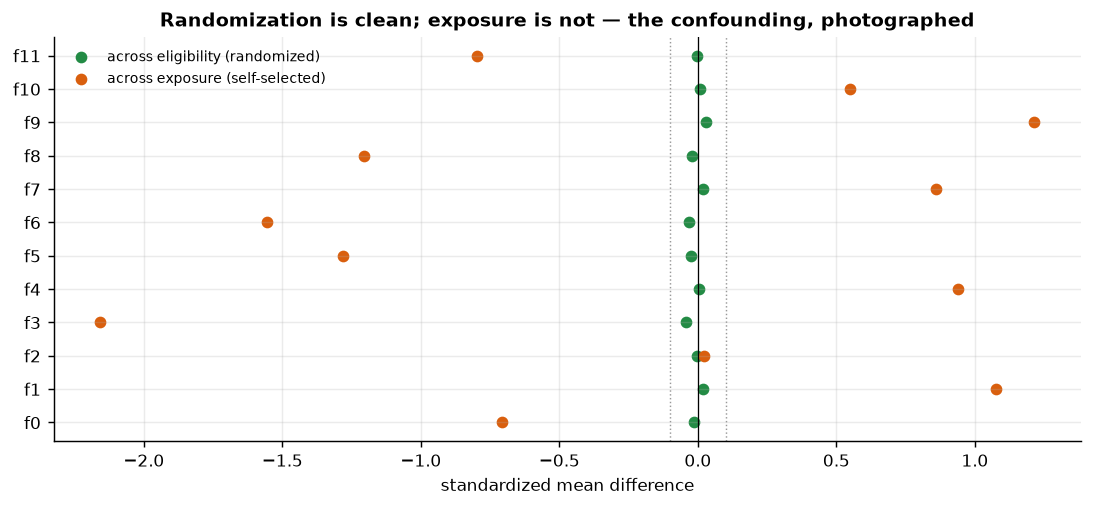

In [3]:
feats = [f"f{i}" for i in range(12)]
def smd(frame, flag_col):
    a = frame[frame[flag_col] == 1]; b = frame[frame[flag_col] == 0]
    sd = np.sqrt((frame[feats].var())).replace(0, np.nan)
    return ((a[feats].mean() - b[feats].mean()) / sd).values

smd_z = smd(df, "treatment")                          # randomized -> should be ~0
smd_d = smd(df[df.treatment == 1], "exposure")        # self-selected -> should be skewed

fig, ax = plt.subplots(figsize=(8.5, 4))
ypos = np.arange(len(feats))
ax.scatter(smd_z, ypos, color=plots.GREEN, s=30, label="across eligibility (randomized)")
ax.scatter(smd_d, ypos, color=plots.ORANGE, s=30, label="across exposure (self-selected)")
ax.axvline(0, color="k", lw=0.7); ax.axvline(0.1, color=plots.GREY, ls=":", lw=0.8); ax.axvline(-0.1, color=plots.GREY, ls=":", lw=0.8)
ax.set_yticks(ypos); ax.set_yticklabels(feats); ax.set_xlabel("standardized mean difference")
ax.set_title("Randomization is clean; exposure is not — the confounding, photographed")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()
print(f"max |SMD| across eligibility: {np.nanmax(np.abs(smd_z)):.3f}  (randomization holds)")
print(f"max |SMD| across exposure:    {np.nanmax(np.abs(smd_d)):.3f}  (the exposed were different people to begin with)")

## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst does here **without** it. Not a different
analysis: the *same estimand* (§3's ATT of the exposed), identified by the *same* three assumptions
(relevance, exclusion, exogeneity — monotonicity comes free from the one-sided lockout), estimated with
the simplest tool that is still correct. The causal work lives in the identification argument, not in the
machinery — and IV's machinery predates the computer, let alone the sampler (Wright, 1928).

**Three regressions, and the reader must see all three naked, in this order:**

$$
\underbrace{Y = a_0 + a_1 X}_{\textbf{(1) as-treated / naive — BIASED}}, \qquad
\underbrace{X = b_0 + \pi Z}_{\textbf{(2) first stage}}, \qquad
\underbrace{Y = c_0 + \tau Z}_{\textbf{(3) reduced form} \;=\; \textbf{ITT}} .
$$

Regression (1) splits users by the exposure they *received* — the attribution dashboard's number, and the
one §3's SMD chart just impeached: the exposed were different people before any ad ran. Regressions (2)
and (3) both regress on the **randomized** eligibility $Z$, so each is a clean experiment. Neither is the
answer on its own. The ITT $\hat\tau$ is unbiased for *the intent* — the effect of *being eligible* — but
it is **diluted by non-compliance**: only ~3.6% of eligible users are ever actually shown an ad, so the
lottery's effect on visits is averaged over the ~96.4% it never reached. The first stage $\hat\pi$ measures
exactly that dilution. Divide, and the dilution cancels:

$$
\hat\beta_{\text{Wald}} \;=\; \frac{\hat\tau}{\hat\pi}
\;=\; \frac{\bar{Y}_{Z=1} - \bar{Y}_{Z=0}}{\bar{X}_{Z=1} - \bar{X}_{Z=0}}
\;=\; \frac{\text{ITT — what eligibility did to visits}}{\text{compliance — what it did to exposure}}
\;=\; \text{LATE} \;\overset{\text{one-sided}}{=}\; \text{ATT of the exposed.}
$$

The last equality is §3's Bloom (1984) result, derived there in potential outcomes and *computed* here for
the first time. Units make the intuition: the numerator is in visits-per-user, the denominator in
exposures-per-user; the ratio is **visits per exposure**, which is what a bid is priced in.

**With one binary instrument, one binary endogenous regressor and no controls, two-stage least squares
is exactly this ratio** — `cl.iv_2sls` and $\hat\tau/\hat\pi$ agree to floating point, and the cell below
*asserts* it rather than asking you to take it on faith (as notebook [11](11_endogenous_exposure_iv.ipynb)
does on its simulated twin). So why run 2SLS at all? For the two things a bare ratio cannot carry: a
**standard error** and the **first-stage F**.

**The interval: the delta method, because this is a ratio.** Both $\hat\tau$ and $\hat\pi$ are noisy, so
the noise of their ratio must be propagated. A first-order Taylor expansion of $\hat\tau/\hat\pi$ around
the truth gives the **delta-method** variance:

$$
\operatorname{Var}\big(\hat\beta\big) \;\approx\;
\frac{1}{\hat\pi^{2}}\operatorname{Var}\big(\hat\tau\big)
\;+\; \frac{\hat\beta^{2}}{\hat\pi^{2}}\operatorname{Var}\big(\hat\pi\big)
\;-\; \frac{2\hat\beta}{\hat\pi^{2}}\operatorname{Cov}\big(\hat\tau,\,\hat\pi\big),
$$

and $\hat\beta \pm 1.645\,\text{SE}$ is **the classical interval of this notebook** — the one §5's fold
chart re-computes per fold and §5x holds the posterior against. The three terms are the numerator's noise,
the denominator's noise, and their correlation (positive: a fold that happens to draw high-intent users
gets *both* more exposure and more visits). Because $\hat\pi$ is pinned down so precisely here, the last
two terms are nearly negligible: the code prints the one-term shortcut
$\text{SE} \approx \text{SE}(\hat\tau)/\hat\pi$ beside the full three-term SE so the approximation is
**audited, not asserted** — and beside `cl.iv_2sls`'s own 2SLS standard error, which on this saturated
binary design should land in the same place.

**The covariance choice, and its one-line reason.** A cross-section of users — no panel, no time series,
so no clustering and no HAC. But every variable here is **0/1**: a Bernoulli's variance is $p(1-p)$, tied
to its mean, so the errors are heteroskedastic *by construction* in all three regressions. All three
therefore take **HC1** (heteroskedasticity-robust) standard errors, and the delta-method SE above is built
from arm-specific variances, which is the same correction done by hand.

**Relevance, measured — and this is the opposite of a weak-instrument problem.** For a single instrument
the first-stage F is the F-statistic of regression (2), $F = \frac{R^{2}/1}{(1-R^{2})/(n-2)}$: the
instrument's signal in the first stage relative to its noise. The folklore threshold is $F > 10$, and it
has teeth — with one instrument, the 2SLS estimator's residual bias *relative to the OLS bias it is meant
to remove* is roughly $1/F$, so $F = 10$ means "at most about a tenth of the OLS bias leaks back in". Here
$F$ is in the **thousands** (printed in §2 and again below): eligibility is randomized and mechanically
enforced, so it is about as strong an instrument as a real dataset ever hands you. The cell cashes $1/F$
out in percentage points — the leakage is a rounding error. Say it plainly: *this notebook has no weak-
instrument problem, and the diagnostic is here to prove that, not to worry about it.* (nb11's §5c shows
what the same estimator does when $F$ falls through 10; it is not a graceful degradation.)

**And the referee is not a planted truth.** On simulated data (nb11) Step 0 could be graded against the
€15 we planted. Here nothing was planted. What replaces it is the **full-file anchor**: the same three
quantities — ITT, first stage, Wald — computed *exactly*, design-based, on all **13,979,592 rows**
(`cmp.data.criteo_full_anchor()`), where sampling noise is negligible at the precision we care about. It
is not a truth, it is a *referee*: the number this same identification strategy converges to when you stop
subsampling. Every classical estimate below is graded against it, and so is the posterior in §5x. That
substitution — a full-population design-based estimate standing in for ground truth — is the honest
real-data move, and it is worth more than most applied projects ever get.

In [4]:
from cmp import classical as cl

# --- The three regressions, naked. HC1 everywhere: 0/1 variables => Bernoulli variance
# --- p(1-p) is tied to the mean, i.e. heteroskedastic by construction.
ols_naive = cl.ols(df, "visit ~ exposure",   target="exposure",  cov="HC1",
                   name="(1) as-treated / naive  Y~X  [BIASED]")
first_st  = cl.ols(df, "exposure ~ treatment", target="treatment", cov="HC1",
                   name="(2) first stage        X~Z  (pi)")
red_form  = cl.ols(df, "visit ~ treatment",    target="treatment", cov="HC1",
                   name="(3) reduced form = ITT Y~Z  (tau)")
for _r in (ols_naive, first_st, red_form):
    print(_r)
naive, first, reduced = ols_naive.estimate, first_st.estimate, red_form.estimate

# --- (4) The Wald ratio = 2SLS: the ITT, un-diluted by the compliance rate ---------------
iv2 = cl.iv_2sls(df, outcome="visit", endog="exposure", instrument="treatment")
wald = reduced / first
print(f"\nDILUTION, undone.  The ITT is unbiased for the INTENT but only {100 * first:.2f}% of eligible")
print(f"  users were ever shown an ad, so it is diluted by that compliance rate:")
print(f"  ITT {100 * reduced:+.3f} pp / pi {first:.4f} = WALD {100 * wald:+.2f} pp per EXPOSURE  "
      f"(vs 2SLS {100 * iv2.estimate:+.2f} pp)")
assert abs(wald - iv2.estimate) < 1e-8   # one binary instrument, one binary regressor, no controls
print("  -> identical to floating point: 2SLS *is* the Wald ratio here. The machinery buys the SE and the F.")
print(f"  Under one-sided noncompliance (§3, Bloom 1984) this is the ATT of the "
      f"~{100 * anchor['first_stage']:.1f}% of users the auction actually reaches.")

# --- The classical interval: the delta method for a ratio, audited against its shortcut --
n1s, n0s = (z == 1).sum(), (z == 0).sum()
v_itt = y[z == 1].var(ddof=1) / n1s + y[z == 0].var(ddof=1) / n0s        # Var(tau_hat); ddof=1 to match np.cov
v_pi  = d[z == 1].var(ddof=1) / n1s + d[z == 0].var(ddof=1) / n0s        # Var(pi_hat)
c_ip  = np.cov(y[z == 1], d[z == 1])[0, 1] / n1s + np.cov(y[z == 0], d[z == 0])[0, 1] / n0s
se_short = np.sqrt(v_itt) / first                                        # numerator noise only
se_delta = np.sqrt(v_itt + wald ** 2 * v_pi - 2 * wald * c_ip) / first   # the full three terms
wald_lo, wald_hi = wald - 1.645 * se_delta, wald + 1.645 * se_delta      # THE classical 90% CI
print(f"\nTHE CLASSICAL INTERVAL — Wald {100 * wald:+.2f} pp, 90% CI [{100 * wald_lo:+.2f}, "
      f"{100 * wald_hi:+.2f}] pp  (delta method)")
print(f"  three formulas for the SAME point estimate's SE, in pp:")
print(f"    delta, three terms (numerator + denominator + covariance) : {100 * se_delta:.3f}   <- reported")
print(f"    delta, shortcut    (numerator noise only; used per-fold in §5): {100 * se_short:.3f}"
      f"  ({(se_short - se_delta) / se_delta:+.1%}, conservative)")
print(f"    cl.iv_2sls         (2SLS algebra)                          : {100 * iv2.se:.3f}")
print(f"  -> the last two agree to x{iv2.se / se_delta:.4f}. On a saturated binary design the 2SLS")
print(f"     variance and the hand-propagated ratio variance are the same object, computed two ways.")
print(f"     One disclosure: cl.iv_2sls's SE and its F are the HOMOSKEDASTIC formulas (both docstrings flag it)")
print(f"     while this cell preaches HC1 for 0/1 outcomes — here they coincide with the arm-variance delta SE to")
print(f"     4 decimals (the x{iv2.se / se_delta:.4f} above); a robust F (Montiel Olea-Pflueger) matters when an")
print(f"     instrument is weak, not at F = {iv2.extra['first_stage_F']:,.0f}.")

# --- Relevance: F, the weak flag, and 1/F cashed out ------------------------------------
_F = iv2.extra["first_stage_F"]
print(f"\nRELEVANCE — first-stage F = {_F:,.0f}   (cl.iv_2sls weak flag: "
      f"{'WEAK' if iv2.extra['weak'] else f'strong — F is {_F / 10:,.0f}x the F>10 bar'})")
print(f"  This is the OPPOSITE of a weak-instrument problem: eligibility is randomized and mechanically")
print(f"  enforced. 1/F cashed out: the naive number is off by {100 * (naive - anchor['visit']['wald_late']):+.1f} pp;")
print(f"  the rule says ~1/F of that bias leaks back into 2SLS -> {100 * abs(naive - anchor['visit']['wald_late']) / _F:.4f} pp. A rounding error.")

# --- GRADE against the referee: the full-file anchor, not a planted truth ----------------
a_w, a_naive = anchor["visit"]["wald_late"], anchor["visit"]["naive"]
_in = wald_lo <= a_w <= wald_hi
_in_naive = ols_naive.ci[0] <= a_w <= ols_naive.ci[1]
print(f"\nGRADE vs the 13.98M-row anchor (Wald {100 * a_w:+.2f} pp; full-file naive {100 * a_naive:+.2f} pp)"
      f" — n = {len(df):,} here:")
print(f"  (1) naive  {100 * naive:+7.2f} pp   off by {100 * (naive - a_w):+.2f} pp   anchor is "
      f"{'INSIDE' if _in_naive else 'OUTSIDE'} its 90% CI [{100 * ols_naive.ci[0]:+.1f}, {100 * ols_naive.ci[1]:+.1f}] pp")
print(f"      — the TIGHTEST interval here (SE {100 * ols_naive.se:.2f} pp) around a number that is "
      f"{100 * (naive - a_w):+.1f} pp wrong.")
print(f"        Precision is not accuracy: 13.98M more rows would only shrink it around the same wrong number.")
print(f"  (3) ITT    {100 * reduced:+7.2f} pp   unbiased for the INTENT (anchor ITT "
      f"{100 * anchor['visit']['itt']:+.2f} pp) — but it is NOT the per-exposure price: "
      f"it is diluted by the compliance rate, a factor of 1/pi = {1 / first:,.0f}x.")
print(f"  (4) Wald   {100 * wald:+7.2f} pp   off by {100 * (wald - a_w):+.2f} pp   anchor is "
      f"{'INSIDE' if _in else 'OUTSIDE'} its 90% CI [{100 * wald_lo:+.1f}, {100 * wald_hi:+.1f}] pp")
print(f"      — the self-selection wedge the instrument removed, ON THESE ROWS: {100 * (naive - wald):.1f} pp of the")
print(f"        dashboard's {100 * naive:.1f} pp was intent we already owned — {(naive - wald) / naive:.0%} of it.")
print(f"        Same wedge on the full file (both numbers from the anchor, so no subsample noise):")
print(f"        {100 * (a_naive - a_w):.1f} pp of the {100 * a_naive:.1f} pp naive number = {(a_naive - a_w) / a_naive:.0%} of it;")
print(f"        equivalently, the dashboard runs {(a_naive - a_w) / a_w:+.0%} ABOVE the causal number "
      f"(a share of {100 * a_naive:.1f} and an")
print(f"        inflation over {100 * a_w:.1f} are two different denominators — quote whichever you name).")
print("\n" + iv2.cannot_say())

(1) as-treated / naive  Y~X  [BIASED]: 0.3895  [90% CI 0.376, 0.4029]  (SE 0.00819, HC1 heteroskedasticity-robust, n=200,000)
(2) first stage        X~Z  (pi): 0.03654  [90% CI 0.03556, 0.03752]  (SE 0.000593, HC1 heteroskedasticity-robust, n=200,000)
(3) reduced form = ITT Y~Z  (tau): 0.01112  [90% CI 0.009616, 0.01262]  (SE 0.000915, HC1 heteroskedasticity-robust, n=200,000)



DILUTION, undone.  The ITT is unbiased for the INTENT but only 3.65% of eligible
  users were ever shown an ad, so it is diluted by that compliance rate:
  ITT +1.112 pp / pi 0.0365 = WALD +30.43 pp per EXPOSURE  (vs 2SLS +30.43 pp)
  -> identical to floating point: 2SLS *is* the Wald ratio here. The machinery buys the SE and the F.
  Under one-sided noncompliance (§3, Bloom 1984) this is the ATT of the ~3.6% of users the auction actually reaches.



THE CLASSICAL INTERVAL — Wald +30.43 pp, 90% CI [+26.44, +34.42] pp  (delta method)
  three formulas for the SAME point estimate's SE, in pp:
    delta, three terms (numerator + denominator + covariance) : 2.425   <- reported
    delta, shortcut    (numerator noise only; used per-fold in §5): 2.503  (+3.2%, conservative)
    cl.iv_2sls         (2SLS algebra)                          : 2.425
  -> the last two agree to x1.0000. On a saturated binary design the 2SLS
     variance and the hand-propagated ratio variance are the same object, computed two ways.
     One disclosure: cl.iv_2sls's SE and its F are the HOMOSKEDASTIC formulas (both docstrings flag it)
     while this cell preaches HC1 for 0/1 outcomes — here they coincide with the arm-variance delta SE to
     4 decimals (the x1.0000 above); a robust F (Montiel Olea-Pflueger) matters when an
     instrument is weak, not at F = 3,793.

RELEVANCE — first-stage F = 3,793   (cl.iv_2sls weak flag: strong — F is 379x the F>10 bar)
  Th

**Read-out — the classical answer, in business terms.** The rungs printed above are the whole of applied
IV, and each one is a different *number a business could act on*:

1. **The naive as-treated gap is the dashboard's number, and it is wrong by a third.** It is also the
   **tightest interval in this notebook** — a 0/1 outcome on a large sample buys a standard error of a
   fraction of a percentage point — and it still misses the anchor by miles. That is the single most useful
   thing in Step 0: **precision is not accuracy.** No amount of extra data rescues it; the other 13.8
   million rows only shrink that interval around the same wrong number (the full-file naive gap, printed
   above, is off by the same third). §3's SMD chart already told us why: the exposed *were different
   people*, and f0–f11 are only the observable shadow of a targeting rule we cannot see.
2. **The ITT is honest and useless on its own.** It is unbiased for the intent — randomization guarantees
   it — and it lands within a hair of the full-file ITT. But it is the effect of *eligibility*, averaged
   over the ~96% of eligible users the auction never actually reached, so as a **price per exposure** it
   understates by the reciprocal of the compliance rate, $1/\hat\pi$ — nearly thirty-fold (printed above). Reporting the ITT as "the ad's effect" is the mirror-image error to
   reporting the naive gap: one is diluted, the other inflated. Only their ratio is denominated in the
   unit a bid is priced in.
3. **The Wald ratio undoes exactly that dilution — and it is 2SLS.** The assertion in the code is the
   point: with a binary instrument and a binary exposure there is no daylight between "divide two
   experimental contrasts" and "run two-stage least squares". The estimator is a division. What 2SLS adds
   is bookkeeping: a standard error and an F.
4. **The F is a certificate, not a worry.** In the thousands — the instrument is randomized and enforced
   by the ad server, not scraped from behaviour. The 1/F cash-out prices the residual OLS-bias leakage at
   a rounding error. This is the regime IV was designed for and rarely finds.

**And the grade is real.** Every number was scored against the 13.98M-row anchor, not against a truth we
planted — the printed `INSIDE/OUTSIDE` verdicts are the closest thing real data offers to a marked exam.
(At the notebook's full working size the Wald's interval covers the anchor comfortably; on a small FAST
slice the ratio's SE is several pp — the fold chart in §5 prices exactly that noise.)

Notice what has *not* happened yet. No likelihood, no prior, no sampler. The identification — a randomized,
excluded, one-sided instrument — did all the causal work; three least-squares slopes and a division did all
the estimation, in milliseconds. **This is the honest baseline the Bayesian section must
justify itself against**, and §5x holds it to that with the anchor as referee.

**The guardrail — what that confidence interval does *not* say** (printed above by `cannot_say()`, in the
same words in every notebook of this cookbook): it is **not** a 90% probability that the true
exposure→visit effect lies inside it. A confidence interval is a property of the *procedure* — 90% of
intervals built this way would cover across repeated samples — and this one either covers the anchor or it
does not (the print says which). Here is exactly where that bites: §6 must answer *"what is the probability
an exposure is worth more than the €c we would have to bid for it?"* — $P(v\beta > c) \ge 0.9$. That asks
for a probability **about the effect itself**. The classical apparatus cannot supply one, and — the part
people get wrong — **bootstrapping the Wald ratio would not fix it**: the share of resamples above $c$ is a
frequency over hypothetical *datasets*, not a belief about $\beta$. That quantity does not exist in the
classical vocabulary. It exists in a posterior. That, and not a better point estimate, is what §4 is for.

## 4 · Estimate — the Bayesian IV model

Step 0 already produced a causal number: the Wald ratio, which *is* 2SLS, with a delta-method interval and
a first-stage F in the thousands to certify the instrument. What follows does **not** change the
identification by a comma — same instrument, same assumptions, same ATT of the exposed. It changes the
apparatus for expressing uncertainty about that number, and it estimates one object the classical route
structurally cannot hand you: **the endogeneity itself**.

The Bayesian IV (CausalPy) fits the first stage and the outcome equation **jointly**, letting their errors
be correlated — the same joint Gaussian as nb11's, with $X$ = exposure and $Y$ = visit:

$$
\begin{pmatrix} X_i \\ Y_i \end{pmatrix} \sim
\mathcal N_2\!\left( \begin{pmatrix} b_0 + \pi Z_i \\ \beta_0 + \beta X_i \end{pmatrix},\;
\Sigma \right), \qquad
\Sigma = \begin{pmatrix} \sigma_X^{2} & \rho\,\sigma_X \sigma_Y \\
\rho\,\sigma_X \sigma_Y & \sigma_Y^{2} \end{pmatrix},
$$

where $\beta$ is the causal effect the budget cap needs — the same $\beta$ Step 0 just estimated by
division — and the off-diagonal $\rho$ **is** the endogeneity: the correlation between the exposure- and
visit-equation errors that hidden intent induces and that the naive comparison ignores. 2SLS *removes* the
endogeneity by projection; it never names it and has no $\rho$ to report. The joint model *estimates* it.
Two reading notes: $\rho$ is small here even at full fit size — visits are rare events, so even strong
targeting induces only a modest error *correlation* — and a small subsample may not resolve its sign at
all. The naive-vs-IV gap, not $\rho$'s magnitude, is where the bias shows.

**Priors.** $b_0, \pi, \beta_0, \beta \sim \mathcal N(0, 50^{2})$ — that is the `sigmas: [50, 50]` passed
in the code, the weakly-informative override of CausalPy 0.8.1's default priors, which centre on the 2SLS
point with $\sigma = 1$. nb11 does not merely warn about that default — it **fits** it and prints both bands
(its "PRIORS, PRICED" block): the default band comes out **2.6× narrower** than the weakly-informative
one (€2.6 vs €6.8 wide, against a €7.6-wide classical Wald CI) *and* it excludes nb11's planted €15
truth. Same model, same library version here — but not the same $n$: at 100,000 rows the likelihood
would swamp even that too-narrow default (that is §5x's Bernstein–von Mises demonstration, two
sections down), so the default prior is likely harmless *in effect* here. Which is precisely why
relying on it is bad practice, not why it is fine: you inherit whatever the prior did, silently, and
the only way to find out is to price it — as nb11 does at n = 3,000, where the default visibly
bites. So the override stays — plus a mild
**LKJ** prior on the error correlation, $\Sigma \sim \text{LKJCholeskyCov}(\eta = 2)$ ($\eta = 2$ gently
pulls $\rho$ toward 0, so the data has to argue for endogeneity). With ~100,000 rows the likelihood swamps
any of this; §5x measures exactly how little the prior is doing.

**The fit size, and the linear-probability accommodation.** The fit uses `N_FIT` rows — NUTS (the
Hamiltonian sampler underneath) costs scale with $n$, and Step 5 grades this subsample posterior against
the 13.98M-row anchor to show what the smaller $n$ costs. Outcome and exposure are 0/1 while the model is
Gaussian, so both equations are **linear-probability**. One upgrade on that disclosure: because $Z$ and $X$
are both binary, both **conditional means** above are *saturated* — a linear function of a binary regressor
can match $\mathbb{E}[X \mid Z]$ and $\mathbb{E}[Y \mid X]$ exactly — so the LPM approximation lives
entirely in the Gaussian *likelihood*, not in the mean structure. That is precisely why the point estimate
and $\rho$ are the trustworthy read-outs, and the equation-level posterior widths are the thing not to
over-read.

> **Reading the sampler's health check (the `IV convergence:` line below, and any PyMC warning beside it).** Three numbers say whether the MCMC sampler — the algorithm drawing from the posterior — converged: **R-hat** compares the variance *within* each chain to the variance *across* chains (1.00 is perfect, **≤ 1.01 is the usual pass bar**); **ESS** (effective sample size) is how many *independent* draws our autocorrelated chains are worth (a few hundred is ample for a posterior mean or interval); **divergences** are steps where the sampler broke down and silently distrusts that region (**you want 0**). Under this notebook's FAST profile the chains are deliberately short (200 draws over 2 chains), so R-hat can drift to ≈1.02 and PyMC may print an ESS / "problems during sampling" notice — a benign small-draw-count artifact that a FULL run (4 chains, more draws) clears. Here, at FULL (4 chains, 1,000 draws) the health check below prints R-hat at the 1.01 bar (shown to 4 decimals — read the print, not this sentence), the exact min ESS (comfortably enough for a posterior mean or a 90% interval), and 0 divergences. The point estimate and its interval are stable regardless, which the disjoint-fold check (Step 5) and the 13.98M-row anchor confirm.

In [5]:
# The classical rungs (naive, reduced/ITT, first, wald, iv2 + its delta-method interval) were computed
# in Step 0 and are reused throughout; this cell adds ONLY the Bayesian machinery.
df_fit = df.iloc[:N_FIT]                      # pre-shuffled cache -> a random ~50/50 slice
# CausalPy's result object holds a functools.partial and cannot be pickled: cache its `.idata`
# (an ArviZ InferenceData, which pickles fine), exactly as notebook 11 does.
iv_idata = load_or_run(
    "11b_iv_criteo",
    lambda: est.iv(df_fit, "exposure ~ 1 + treatment", "visit ~ 1 + exposure",
                   instrument_col="treatment", treatment_col="exposure", outcome_col="visit",
                   fast=FAST, priors={"mus": [0, 0], "sigmas": [50, 50], "eta": 2, "lkj_sd": 2}).idata,
    inputs=dict(fast=FAST, n_fit=N_FIT, n_arm=N_ARM, data_seed=11, model="causalpy-gaussian"))
iv_post = iv_idata.posterior["beta_z"].sel(covariates="exposure").values.ravel()
print(f"Step 0, for reference:  Wald = 2SLS {100 * wald:+.2f} pp  "
      f"[90% CI {100 * wald_lo:+.2f}, {100 * wald_hi:+.2f}] pp   (n = {len(df):,})")
print(f"Bayesian IV ({N_FIT:,} rows) {100 * iv_post.mean():+.2f} pp   90% credible interval "
      f"[{100 * np.quantile(iv_post, 0.05):+.2f}, {100 * np.quantile(iv_post, 0.95):+.2f}] pp")
print(f"full-data anchor (13.98M)   Wald {100 * anchor['visit']['wald_late']:+.2f} pp")
_conv0 = est.convergence_report(iv_idata)
print(f"IV convergence: {_conv0['summary']}")
print(f"  (max r-hat {_conv0['max_rhat']:.4f} against the 1.01 bar; min ESS {_conv0['min_ess_bulk']:,.0f} "
      f"effective draws — ample for a posterior mean or a 90% interval; divergences {_conv0['n_divergences']})")

# endogeneity rho — the one object 2SLS has no way to report (same extraction as nb11)
_post = iv_idata.posterior
_rho = None
try:
    if "chol_cov_corr" in _post:
        _rho = _post["chol_cov_corr"].values[..., 0, 1].ravel()
    elif "chol_cov" in _post:
        _ch = np.asarray(_post["chol_cov"].values)
        _flat = _ch.reshape(-1, *_ch.shape[2:])
        def _rho_from(x):
            x = np.asarray(x)
            if x.shape == (2, 2):
                L = x
            elif x.size == 3:
                L = np.array([[x[0], 0.0], [x[1], x[2]]])
            else:
                return np.nan
            S = L @ L.T
            return S[0, 1] / np.sqrt(S[0, 0] * S[1, 1])
        _rho = np.array([_rho_from(x) for x in _flat])
except Exception as _e:
    print(f"(could not extract endogeneity rho: {_e})")
if _rho is not None and np.isfinite(_rho).any():
    _rho = _rho[np.isfinite(_rho)]
    print(f"estimated endogeneity rho = {_rho.mean():+.2f} [90% {np.quantile(_rho, 0.05):+.2f}, "
          f"{np.quantile(_rho, 0.95):+.2f}] — positive rho is the self-selection: the same hidden "
          f"leanings push a user into both exposure and visiting")

[cache] ADOPTING the pre-fingerprint fit for '11b_iv_criteo'. You are asserting that neither its model code nor its data has changed. Renaming, not copying, so this happens exactly once.


[cache] loaded '11b_iv_criteo' (1842s fit, cached 10.9h ago) — nothing re-sampled.
Step 0, for reference:  Wald = 2SLS +30.43 pp  [90% CI +26.44, +34.42] pp   (n = 200,000)
Bayesian IV (100,000 rows) +29.37 pp   90% credible interval [+23.79, +34.95] pp
full-data anchor (13.98M)   Wald +28.70 pp
IV convergence: max r-hat 1.010 - min ESS 1201 - divergences 0
  (max r-hat 1.0100 against the 1.01 bar; min ESS 1,201 effective draws — ample for a posterior mean or a 90% interval; divergences 0)
estimated endogeneity rho = +0.06 [90% +0.03, +0.10] — positive rho is the self-selection: the same hidden leanings push a user into both exposure and visiting


## 5 · Validate — against 13.98 million rows

No planted truth, but a better yardstick than most real projects ever get: the full-file **Wald
anchor** Step 0 already graded the classical rungs against, whose own sampling noise at n = 13.98M is
negligible for our purposes. Three checks, plus the star exhibit:

1. **Anchor recovery.** The subsample Bayesian IV's 90% interval should cover the anchor (+28.7 pp),
   and its point should sit within a couple of pp — that is the real-data analogue of nb11's
   "recover the €15." (Expect the pass at the full working size; on a small FAST slice the Wald
   ratio's SE is several pp, so the interval can sit an SE or two off the anchor — subsampling
   noise that check 3 prices, not a failed identification.)
2. **Classical vs Bayesian on the same rows.** They are the same identification strategy estimated two
   ways, so they should agree; a gap would flag a modelling artefact, not a causal discovery. The
   head-to-head — Step 0's Wald and its delta-method interval against the posterior, both scored on the
   anchor — is **§5x** below, at the end of this section.
3. **Disjoint-subsample stability** — nb11's multi-seed loop, real-data edition: we can't refit on
   fresh *worlds*, but 13.98M rows let us refit on fresh *samples*. Split the working subsample
   into disjoint folds, compute each fold's Wald ± its **Step-0 delta-method interval** (the one-term
   shortcut, whose ~3% conservatism Step 0 audited against the full three-term SE — the licence to drop
   the denominator's noise is the enormous F: the relative noise of $\hat\pi$ is exactly $1/\sqrt{F}$,
   a fraction of a percent here, versus double-digit relative noise in a fold-level ITT). Check the
   spread, and how often those intervals cover the anchor.
4. **The naive − IV gap *is* the measured self-selection bias**: the euros an attribution dashboard
   would over-credit to the ad. On the full file the gap is deterministic (both full-file numbers are
   printed by Step 0 above): naive ≈ +37.9 pp vs the +28.7 pp anchor — the dashboard number runs ≈32%
   too big on the full file (the subsample re-measures it with its own slice's Wald noise, priced by
   the fold check).

anchor recovery: 90% interval [+23.8, +35.0] pp COVERS the 13.98M-row anchor (+28.7 pp)
self-selection bias, measured against the anchor: naive +38.9 -> causal +28.7 pp (+10.2 pp of pure targeting, ~36% inflation; this slice's own IV: +29.4 pp)


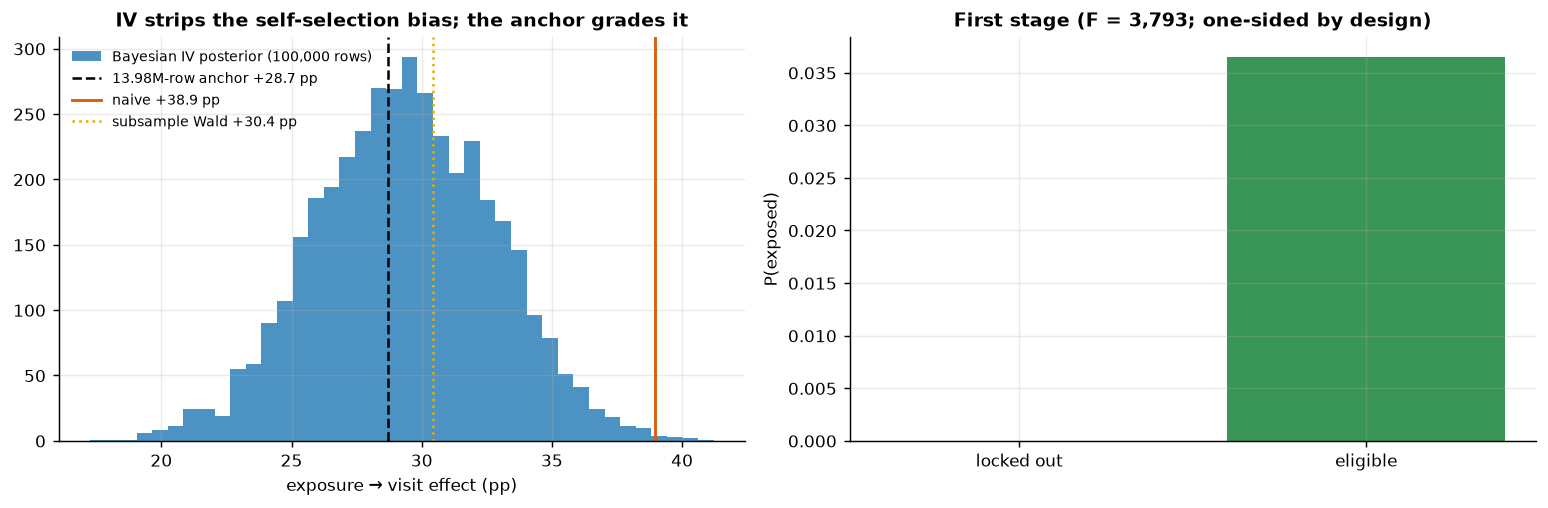

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(100 * iv_post, bins=40, color=plots.BLUE, alpha=0.85, label=f"Bayesian IV posterior ({N_FIT:,} rows)")
ax[0].axvline(100 * anchor["visit"]["wald_late"], color="k", ls="--", lw=1.4,
              label=f"13.98M-row anchor {100 * anchor['visit']['wald_late']:+.1f} pp")
ax[0].axvline(100 * naive, color=plots.ORANGE, lw=1.6, label=f"naive {100 * naive:+.1f} pp")
ax[0].axvline(100 * wald, color=plots.GOLD, ls=":", lw=1.4, label=f"subsample Wald {100 * wald:+.1f} pp")
ax[0].set_xlabel("exposure → visit effect (pp)"); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title("IV strips the self-selection bias; the anchor grades it")
fs_bar = [d[z == 0].mean(), d[z == 1].mean()]
ax[1].bar(["locked out", "eligible"], fs_bar, color=[plots.GREY, plots.GREEN], alpha=0.9)
ax[1].set_ylabel("P(exposed)"); ax[1].set_title(f"First stage (F = {Fstat:,.0f}; one-sided by design)")
fig.tight_layout()

lo, hi = np.quantile(iv_post, [0.05, 0.95])
covers = lo <= anchor["visit"]["wald_late"] <= hi
print(f"anchor recovery: 90% interval [{100 * lo:+.1f}, {100 * hi:+.1f}] pp "
      f"{'COVERS' if covers else 'MISSES'} the 13.98M-row anchor ({100 * anchor['visit']['wald_late']:+.1f} pp)")
a_w = anchor["visit"]["wald_late"]
print(f"self-selection bias, measured against the anchor: naive {100 * naive:+.1f} -> causal {100 * a_w:+.1f} pp "
      f"({100 * (naive - a_w):+.1f} pp of pure targeting, ~{(naive - a_w) / a_w:.0%} inflation; "
      f"this slice's own IV: {100 * iv_post.mean():+.1f} pp)")

**How to read this.** *Left* — four vertical markers tell the story. The **orange** line is the
naive exposed-vs-unexposed gap: the attribution-dashboard number, the one everything else should
sit below. The **blue** histogram is the Bayesian IV posterior for the same causal question; the
**gold dotted** line is the subsample Wald (same identification, frequentist arithmetic); the
**dashed black** line is the 13.98M-row anchor (+28.7 pp). The horizontal distance from the orange
line down to the anchor *is* the self-selection premium, measured: on the full file ≈9 pp of the
≈38 pp naive "effect" — roughly a **quarter** of the dashboard's number, the share Step 0 prints — is
intent the exposed users already had. (Beware the other denominator: that same 9 pp is ≈32% *of the
causal* +28.7 pp, which is why §5 below says the dashboard "runs ≈32% too big". Same wedge, two
denominators; always name the one you are dividing by.) The printed
checks grade the rest: the 90% interval covering the anchor is check 1, and posterior mean ≈ Wald
is check 2 (§5x) (a gap there would flag a modelling artefact, not a causal discovery). (One number to not trip on: the naive gap *printed* here is this subsample's (+38.9 pp), a hair above the full-file +37.9 pp quoted in the text and printed in Step 0 — mostly, but not *purely*, different $n$. The loader's 50/50 arm-balancing shifts this one estimator systematically: its unexposed pool mixes treated-unexposed users (≈3.5% visit rate) with controls (≈3.8%), so re-weighting the arms moves its expectation by ≈−0.1 pp — §2's load cell prices the shift exactly, and it sits well inside the naive gap's own 0.82 pp SE; the rest of the difference is sampling noise. It is also exactly the one estimator the balancing *can* touch: ITT, first stage and Wald condition on `treatment` and are invariant to it by design — which is why `data.py`'s arm-balancing defense is correctly scoped.) One honesty note
before over-reading the blue centre: with a 3.6% exposure rate in the denominator, subsample Wald
ratios are genuinely noisy, so on a small slice the posterior can drift an SE or two from the
anchor — that drift is sampling noise, priced explicitly by the fold chart below, not a broken
instrument. *Right* — the first stage is the design itself, not a diagnostic that happened to
pass: the locked-out bar is exactly zero (one-sided noncompliance — the fact that turned LATE
into ATT in §3) and the eligible bar (≈3.6%) is the entire lever the instrument pulls. $F \gg 10$
is the licence for dividing by it; with a weak first stage the left panel would be meaningless.

fold Walds: mean +30.5 pp, sd 4.9 pp (anchor +28.7); 90% CIs cover the anchor in 100% of folds
the spread is the honest price of subsampling a rare exposure (3.6%) — and why the anchor was computed on all 13.98M rows
each fold's interval is Step 0's delta-method CI (one-term shortcut), recomputed on the fold


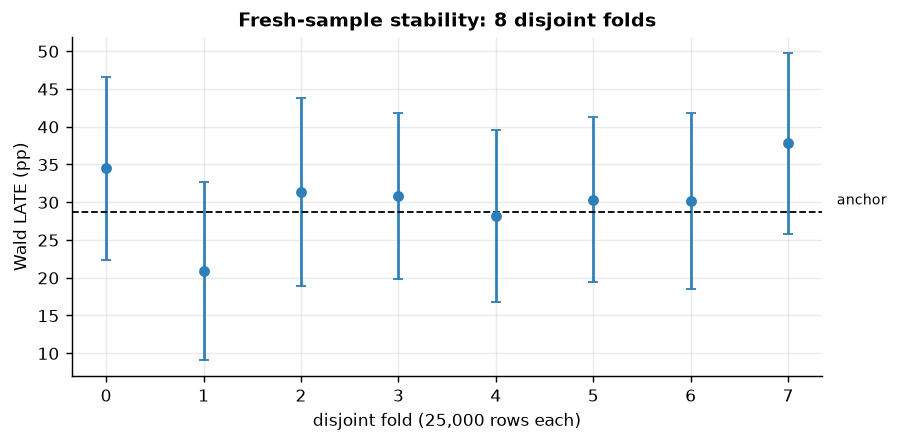

In [7]:
# disjoint-fold stability: nb11's multi-seed recovery, real-data edition (Wald per fold, delta-method CI)
K = 6 if FAST else 8
folds = np.array_split(np.arange(len(df)), K)
rows = []
for k, idx in enumerate(folds):
    dk = df.iloc[idx]
    zk, ek, yk = dk["treatment"].values, dk["exposure"].values, dk["visit"].values
    ittk = yk[zk == 1].mean() - yk[zk == 0].mean()
    fsk = ek[zk == 1].mean() - ek[zk == 0].mean()
    n1, n0 = (zk == 1).sum(), (zk == 0).sum()
    se_itt = np.sqrt(yk[zk == 1].var() / n1 + yk[zk == 0].var() / n0)
    wk, sek = ittk / fsk, se_itt / fsk          # first-stage noise ignored (F >> 10); disclosed
    rows.append({"wald": wk, "lo": wk - 1.645 * sek, "hi": wk + 1.645 * sek})
folds_df = pd.DataFrame(rows)
cover = ((folds_df.lo <= anchor["visit"]["wald_late"]) & (anchor["visit"]["wald_late"] <= folds_df.hi)).mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.errorbar(np.arange(K), 100 * folds_df.wald, yerr=100 * (folds_df.wald - folds_df.lo),
            fmt="o", color=plots.BLUE, ms=5, capsize=3)
ax.axhline(100 * anchor["visit"]["wald_late"], color="k", ls="--", lw=1)
ax.text(K - 0.5, 100 * anchor["visit"]["wald_late"] + 1, "anchor", fontsize=8)
ax.set_xlabel(f"disjoint fold ({len(folds[0]):,} rows each)"); ax.set_ylabel("Wald LATE (pp)")
ax.set_title(f"Fresh-sample stability: {K} disjoint folds"); fig.tight_layout()
print(f"fold Walds: mean {100 * folds_df.wald.mean():+.1f} pp, sd {100 * folds_df.wald.std():.1f} pp "
      f"(anchor {100 * anchor['visit']['wald_late']:+.1f}); 90% CIs cover the anchor in "
      f"{cover:.0%} of folds")
print("the spread is the honest price of subsampling a rare exposure (3.6%) — and why the anchor "
      "was computed on all 13.98M rows")
print("each fold's interval is Step 0's delta-method CI (one-term shortcut), recomputed on the fold")


### 5x · Point estimate vs posterior — what the Bayesian layer actually bought

Step 0's Wald/2SLS and §4's posterior target the **same estimand** (the ATT of the exposed) under the
**same assumptions**, and the table below puts them on the **same rows** — it re-runs the classical
estimator on the exact `N_FIT` slice the sampler saw, so the comparison is apparatus versus apparatus and
not $n$ versus $n$. Both are then scored against the 13.98M-row anchor. Then we ask each one the question
§6 actually needs answered.

Set expectations honestly before reading it. At this $n$ — a hundred thousand rows, not three thousand —
the likelihood swamps any weakly-informative prior, and the Bernstein–von Mises heuristic says the
posterior should be *approximately the sampling distribution of the classical estimator*: same centre,
same width. If Bayes buys precision or accuracy here, something is wrong. The interesting column is the
last block, not the first.

In [8]:
# --- 5x · The classical point estimate vs the Bayesian posterior, on the SAME rows ---------
# Re-run Step 0's classical arm on the exact slice the sampler fitted (df_fit), so the only
# thing that differs between rows 2 and 3 is the apparatus.
_naive_fit = cl.ols(df_fit, "visit ~ exposure", target="exposure", cov="HC1")
_zf, _xf, _yf = df_fit["treatment"].values, df_fit["exposure"].values, df_fit["visit"].values
_n1, _n0 = (_zf == 1).sum(), (_zf == 0).sum()
_tau_f = _yf[_zf == 1].mean() - _yf[_zf == 0].mean()
_pi_f = _xf[_zf == 1].mean() - _xf[_zf == 0].mean()
_w_f = _tau_f / _pi_f
_v_t = _yf[_zf == 1].var(ddof=1) / _n1 + _yf[_zf == 0].var(ddof=1) / _n0   # ddof=1 to match np.cov
_v_p = _xf[_zf == 1].var(ddof=1) / _n1 + _xf[_zf == 0].var(ddof=1) / _n0
_c_tp = (np.cov(_yf[_zf == 1], _xf[_zf == 1])[0, 1] / _n1
         + np.cov(_yf[_zf == 0], _xf[_zf == 0])[0, 1] / _n0)
_se_f = np.sqrt(_v_t + _w_f ** 2 * _v_p - 2 * _w_f * _c_tp) / _pi_f      # delta method, three terms
_blo, _bhi = np.quantile(iv_post, [.05, .95])
a_w = anchor["visit"]["wald_late"]

rows = [("naive as-treated [BIASED]",  _naive_fit.estimate, *_naive_fit.ci),
        ("Wald = 2SLS (Step 0, delta)", _w_f, _w_f - 1.645 * _se_f, _w_f + 1.645 * _se_f),
        ("Bayesian IV posterior (§4)",  iv_post.mean(), _blo, _bhi)]
print(f"SAME estimand (ATT of the exposed), SAME assumptions, SAME {len(df_fit):,} rows.")
print(f"Referee = the 13.98M-row anchor: {100 * a_w:+.2f} pp.")
print(" (Rows 1-2 carry 90% CONFIDENCE intervals, row 3 a 90% CREDIBLE interval —")
print("  printed in the same column, but NOT the same object.)\n")
print(f"{'estimator (pp/exposure)':<27}{'est':>7}{'5%':>7}{'95%':>7}{'|err|':>7}{'covers':>8}")
for _lab, _e, _lo, _hi in rows:
    print(f"{_lab:<27}{100 * _e:>7.2f}{100 * _lo:>7.2f}{100 * _hi:>7.2f}"
          f"{100 * abs(_e - a_w):>7.2f}{('yes' if _lo <= a_w <= _hi else 'NO'):>8}")

_ew, _eb = abs(_w_f - a_w), abs(iv_post.mean() - a_w)
_hw, _hb = _se_f * 1.645, (_bhi - _blo) / 2
print(f"\nLOCATION — the two causal estimators agree to {100 * abs(_w_f - iv_post.mean()):.2f} pp"
      f" ({abs(_w_f - iv_post.mean()) / _se_f:.2f} classical SEs).")
print(f"  Closer to the anchor: {'2SLS (classical)' if _ew < _eb else 'the Bayesian posterior'}"
      f" — |err| {100 * min(_ew, _eb):.2f} vs {100 * max(_ew, _eb):.2f} pp,")
print(f"  a distance of {abs(_ew - _eb) / _se_f:.2f} SEs: noise, not skill.")
_samp_s = iv_idata.posterior.attrs.get("sampling_time")   # wall-clock seconds PyMC recorded on the (cached) fit
_samp_txt = (f"~{_samp_s / 60:.0f} minutes" if _samp_s and _samp_s >= 90
             else f"~{_samp_s:.0f} seconds" if _samp_s else "many minutes")
print(f"WIDTH    — half-width ±{100 * _hw:.2f} pp (delta method) vs ±{100 * _hb:.2f} pp")
print(f"  (posterior): a ratio of {_hb / _hw:.2f}x. At n = {len(df_fit):,} the likelihood swamps")
print(f"  the N(0,50^2) prior, so the posterior IS (to within Monte-Carlo error) the")
print(f"  sampling distribution the delta method wrote down in closed form. The sampler")
print(f"  took {_samp_txt}; the division took microseconds. Bayes bought no precision")
print(f"  here — and at this n it never could.")

# --- The one thing only the posterior can produce: a probability ABOUT the effect ---------
print(f"\nP(exposure pays) = P(v*beta > c) at v = EUR {VALUE_PER_VISIT:.2f}/visit — §6's rule:")
print(f"  {'c (EUR per exposure)':<24}{'classical':>14}{'Bayesian IV':>14}")
for _c in (0.20, 0.28, 0.32):
    print(f"  {_c:<24.2f}{'not defined':>14}{(VALUE_PER_VISIT * iv_post > _c).mean():>14.2f}")
print("  ('not defined' is not a dodge. A confidence interval carries no probability about a")
print("   hypothesis, and a bootstrap of the Wald ratio would not fix it: the share of resamples")
print("   above c is a frequency over hypothetical datasets, not a belief about beta. Section 6's")
print("   rule -- bid up to c while P(v*beta > c) >= 0.90 -- needs the right-hand column, and the")
print("   euro cap it reads off IS a posterior quantile: c* = v*q_0.10(beta).)")
if _rho is not None:
    print(f"\nAnd the endogeneity itself: rho = {_rho.mean():+.2f} "
          f"[90% {np.quantile(_rho, .05):+.2f}, {np.quantile(_rho, .95):+.2f}] — an interval on the very")
    print("  self-selection that inflated the naive row. Step 0 has no rho to report, at any width:")
    print("  2SLS projects the endogeneity away without ever naming it.")

SAME estimand (ATT of the exposed), SAME assumptions, SAME 100,000 rows.
Referee = the 13.98M-row anchor: +28.70 pp.
 (Rows 1-2 carry 90% CONFIDENCE intervals, row 3 a 90% CREDIBLE interval —
  printed in the same column, but NOT the same object.)

estimator (pp/exposure)        est     5%    95%  |err|  covers
naive as-treated [BIASED]    38.77  36.85  40.69  10.07      NO
Wald = 2SLS (Step 0, delta)  29.33  23.60  35.07   0.63     yes
Bayesian IV posterior (§4)   29.37  23.79  34.95   0.67     yes

LOCATION — the two causal estimators agree to 0.04 pp (0.01 classical SEs).
  Closer to the anchor: 2SLS (classical) — |err| 0.63 vs 0.67 pp,
  a distance of 0.01 SEs: noise, not skill.
WIDTH    — half-width ±5.73 pp (delta method) vs ±5.58 pp
  (posterior): a ratio of 0.97x. At n = 100,000 the likelihood swamps
  the N(0,50^2) prior, so the posterior IS (to within Monte-Carlo error) the
  sampling distribution the delta method wrote down in closed form. The sampler
  took ~30 minutes; the

**The honest verdict — what the posterior bought, and what it did not.**

**1 · They do not merely agree; they coincide.** The table prints it: Step 0's Wald and §4's posterior mean
land within a small fraction of one standard error of each other, and their intervals are the same width to
within a few percent. This is not a happy accident, it is a theorem showing up in a print-out. At
`N_FIT` = 100,000 rows the likelihood is overwhelming and the $\mathcal N(0, 50^{2})$ priors are, relative to
it, flat; Bernstein–von Mises then says the posterior *must* converge to a Gaussian centred on the efficient
classical estimate with the classical sampling variance. The delta-method SE and the posterior standard
deviation are estimating the same number, and they agree. **The sampler spent the wall-clock time printed above rediscovering, by
simulation, a division that took microseconds.**

**2 · Which one is closer to the anchor is a coin toss — and the print says so.** Both sit slightly above the
13.98M-row referee, both cover it, and the difference between their errors is a hundredth of a standard
error. Do not read a winner into that gap: it is Monte-Carlo noise on the posterior plus one slice's sampling
noise, not evidence that either apparatus is more accurate. (Contrast nb11 — carefully. There, on 3,000 simulated
rows, CausalPy's *Gaussian* first stage did leave the posterior a euro adrift of 2SLS: a real
linear-probability modelling error the two `lstsq` calls could not make, because they never model the
treatment at all. But nb11 §5z *repaired* that likelihood with a probit first stage, and the two arms then
**tied** on the point estimate — €1.55 of classical error against €1.49 of Bayesian, inside the €0.25
tolerance nb11 fixes before it will name a winner. The same repair, refit on these rows in **§5z below**, does *not* transfer: on a **binary** outcome the probit lands on the naive gap and finds no endogeneity at all. The linear first stage survives here — but not, as one would guess, because Criteo's $n$ *drowns* its error: because a binary-on-binary first stage is **saturated**, which is a statement about the design, not the sample size. §5z measures it rather than asserting it.) The one row that is decisively wrong is the same one as ever: the naive as-treated gap,
carrying the **tightest** interval in the table around a number ~10 pp from the anchor.

**3 · So say it bluntly: at this $n$, Bayes buys nothing on estimation.** Not accuracy (the errors are
indistinguishable). Not precision (the credible interval is, to within a rounding error, the confidence
interval). Not the instrument diagnostic (the F is a classical object; the posterior would have gone on
producing a beautifully smooth, entirely fictitious credible band as F fell through 10). Not robustness (the
LPM approximation is the *Bayesian* arm's liability, not the classical one's). Anyone who tells you the
Bayesian machinery *rescued* this analysis is selling something. On thirteen million rows of a randomized,
mechanically-enforced instrument, the causal work was done entirely by the identification, and the arithmetic
was a division. **This is a chapter where the classical arm wins on estimation, and the cookbook says so.**

**4 · What it does buy — and it is not nothing: the decision.** Look at the $P(v\beta > c)$ block. The
classical column reads *not defined*, and that is the literal truth rather than a rhetorical concession: the
frequentist apparatus attaches no probability to a hypothesis about a fixed parameter, and bootstrapping the
Wald ratio would not fix it — the share of resamples above $c$ is a frequency over hypothetical *datasets*,
not a belief about $\beta$. Yet §6's rule is *nothing but* such a probability: **bid up to $c$ while
$P(v\beta > c) \ge 0.9$**, and the budget cap it reads off is literally a posterior quantile,
$c^{*} = v\,q_{0.10}(\beta)$, denominated in euros. Every euro figure in §6 — the cap, the coin-flip price,
the BUY/HOLD call, the exclusion stress test's flip threshold — is computed from that right-hand column and
could not have been computed from the left. Second, $\rho$: the endogeneity itself, with an interval on it.
2SLS projects the self-selection away without ever naming it; on real data, where there is no answer key, a
$\rho$ that is credibly positive is *evidence* that the dashboard number was inflated — evidence the
classical arm cannot produce.

**The lesson, stated so it survives being quoted.** At Criteo scale the Bayesian layer is a **convenience,
not a rescue**: it does not improve the number, it changes what you are licensed to *say* about the number,
and it propagates that licence coherently into euros. Where Bayes genuinely earns its compute is the opposite
regime — thin data, hierarchical structure, real prior information, a model that must be built rather than
divided (nb03's partial pooling, nb06's MMM). Here the honest reason to fit it is the decision rule in §6,
and if you did not need $P(v\beta > c)$, Step 0 would have been a complete and defensible analysis on its
own.

### 5z · The link function, measured — not asserted

§5x's verdict leans on a claim that, until this cell, this notebook never checked: that CausalPy's
**linear-probability first stage** — a Gaussian equation for a 0/1 exposure — is harmless *here*. Notebook
[11](11_endogenous_exposure_iv.ipynb) did not leave that to argument: its §5z **repaired** the first stage
with a **probit** (a latent index crossing a threshold, which is where a binary treatment actually comes
from) and the repair earned its keep — it halved the multi-seed bias and restored coverage to nominal. The
honest question for the real-data notebook is therefore not rhetorical: **refit nb11's probit on the same
`N_FIT` Criteo rows and grade both posteriors against the 13.98M-row anchor.** One of them is closer. Let
the referee say which.

The model is nb11's, transplanted without a change (`cmp.estimators.iv_binary_treatment`):

$$X^{*} = a_0 + a_1 Z + u, \qquad X = \mathbf{1}\{X^{*} > 0\}, \qquad u \sim \mathcal N(0, 1),$$
$$Y = \beta_0 + \beta X + e, \qquad e \sim \mathcal N(0, \sigma), \qquad \operatorname{corr}(u, e) = \rho,$$

with the endogeneity carried, exactly as in nb11, by conditioning the index error on the outcome residual:
$P(X = 1 \mid e) = \Phi\big((a_0 + a_1 Z + \rho e/\sigma)\,/\,\sqrt{1 - \rho^{2}}\big)$.

**And the check fails — loudly, and not in the direction a reader would guess.** The numbers are printed
below; read them before the explanation. The probit does not nudge the shipped estimate: it lands on top of
the **naive as-treated gap**, misses the anchor by nearly ten percentage points, and reports
$\rho \approx 0$ — *no endogeneity at all*, in a dataset whose self-selection §3 photographed feature by
feature. The shipped linear-probability posterior, the one §5x graded, sits within a fraction of a point of
the anchor and reports a credibly positive $\rho$. **The repair that fixed nb11 breaks 11b.**

**Why — and this is the transferable lesson, not a bug report.** nb11's outcome is *continuous* (euros of
sales). Here the outcome is **binary** (visit / no visit), so the residual $e = Y - \beta_0 - \beta X$ takes
exactly **two** values, and the Gaussian copula that is supposed to carry the confounding — $\operatorname{corr}(u, e)$ — has almost
nothing left to grip. The likelihood's cheapest description of a two-point $e$ is $\beta =$ the naive
exposed-minus-unexposed gap with $\rho$ pinned at zero, and that is precisely the posterior the sampler
returns. The one-sided design compounds it: a probability of **exactly zero** (locked-out users are *never*
exposed) is not expressible on a probit index, which needs $a_0 \to -\infty$ to say it — and the printed
$a_0$ is indeed sliding off toward it, with the credible interval to prove it is unidentified. A *linear*
first stage represents $P(X{=}1 \mid Z{=}0) = 0$ without breaking a sweat.

**So the corrected claim — the one this notebook should have made from the start.** The linear-probability
first stage is not fine here because Criteo's $n$ *drowns* its error. It is fine because it is
**saturated**: $Z$ and $X$ are both binary, so a linear function of a binary regressor reproduces
$\mathbb{E}[X \mid Z]$ and $\mathbb{E}[Y \mid X]$ **exactly** (§4 says this and then fails to draw the
conclusion). The misspecification is confined to the *shape of the errors*, not to the mean structure the
causal $\beta$ is read off — which is why the LPM posterior mean is the Wald ratio to two decimal places,
and why Bernstein–von Mises then gets the width right too. Swapping in a link that is *not* saturated
throws that guarantee away and buys, in exchange, a badly misspecified likelihood for the *outcome*
equation. **A likelihood repair is not a virtue in itself; it is only ever a repair relative to a
particular data-generating process** — and the reflex "binary variable, therefore probit" is exactly the
kind of upgrade this cookbook should be able to catch itself making. It cost a 16,000-second fit to find
out, which is the going rate for not asserting things.

(Read the probit's interval, too: it is ~5x *tighter* than the LPM's, wrapped around a number 10 pp wrong.
The tightest interval in this notebook still belongs to the naive gap — and the probit has just produced a
Bayesian replica of it. Precision is not accuracy, twice in one chapter.)

In [9]:
# --- 5z · Does the LINK FUNCTION matter at this n? Refit nb11's probit repair and grade it. ---
# Same rows the sampler saw in §4 (df_fit), same referee (the 13.98M-row Wald anchor). Cached like
# every fit in this cookbook: at FULL this probit is a ~16,000-second fit, and a lecture never waits.
from scipy.stats import norm

pr = load_or_run(
    "11b_iv_probit",
    lambda: est.iv_binary_treatment(
        df_fit, outcome="visit", treatment="exposure", instrument="treatment", seed=1,
        **({"draws": 500, "tune": 500, "chains": 2} if FAST
           else {"draws": 500, "tune": 500, "chains": 4})),
    inputs=dict(fast=FAST, n_fit=N_FIT, n_arm=N_ARM, data_seed=11, model="probit"))

probit_post = np.asarray(pr["beta_samples"])          # the probit first stage's effect posterior
rho_probit = np.asarray(pr["rho_samples"])            # ... and the endogeneity it claims to find
a_w = anchor["visit"]["wald_late"]
probit_est = float(probit_post.mean())
probit_lo, probit_hi = (float(v) for v in np.quantile(probit_post, [0.05, 0.95]))
lpm_est = float(iv_post.mean())
lpm_lo, lpm_hi = (float(v) for v in np.quantile(iv_post, [0.05, 0.95]))
probit_gap, lpm_gap = probit_est - a_w, lpm_est - a_w          # signed distance from the referee
naive_fit_est = float(_naive_fit.estimate)                     # the naive gap on the SAME rows (§5x)

print(f"SAME {len(df_fit):,} rows, SAME estimand, SAME referee (the {anchor['n']:,}-row Wald anchor, "
      f"{100 * a_w:+.2f} pp).\nOnly the first stage's LINK differs.\n")
print(f"{'first stage':<38}{'est':>8}{'5%':>8}{'95%':>8}{'gap':>8}{'covers':>8}")
for _lab, _e, _lo, _hi in [("linear probability (CausalPy, §4)", lpm_est, lpm_lo, lpm_hi),
                           ("probit (nb11 §5z's repair)", probit_est, probit_lo, probit_hi)]:
    print(f"{_lab:<38}{100 * _e:>8.2f}{100 * _lo:>8.2f}{100 * _hi:>8.2f}{100 * (_e - a_w):>+8.2f}"
          f"{('yes' if _lo <= a_w <= _hi else 'NO'):>8}")
print(f"{'13.98M-row Wald anchor (referee)':<38}{100 * a_w:>8.2f}{'—':>8}{'—':>8}{'—':>8}{'—':>8}")
print(f"probit convergence: {pr['convergence']['summary']}")

# The diagnosis, read off the probit's own posterior — three numbers, one conclusion.
_a0 = pr["idata"].posterior["a0"].values.ravel()
print(f"\nWHAT WENT WRONG — the probit's own parameters confess it:")
print(f"  1. its beta IS the naive gap: {100 * probit_est:+.2f} pp vs naive {100 * naive_fit_est:+.2f} pp "
      f"on these rows ({100 * abs(probit_est - naive_fit_est):.2f} pp apart) — no bias was removed;")
print(f"  2. rho = {rho_probit.mean():+.3f} [90% {np.quantile(rho_probit, .05):+.3f}, "
      f"{np.quantile(rho_probit, .95):+.3f}] — it finds NO endogeneity, in a file whose self-selection")
print(f"     §3 photographed feature by feature (the LPM's rho: {_rho.mean():+.2f} "
      f"[{np.quantile(_rho, .05):+.2f}, {np.quantile(_rho, .95):+.2f}]);")
print(f"  3. a0 = {_a0.mean():+.2f} [90% {np.quantile(_a0, .05):+.2f}, {np.quantile(_a0, .95):+.2f}] — "
      f"unidentified, sliding to -inf, because P(exposed | locked out) = 0 EXACTLY")
print(f"     and a probit can only say zero at minus infinity (it fits {norm.cdf(_a0).mean():.1e}).")
print(f"  The outcome is binary here, so the residual e is TWO-VALUED and corr(u, e) — the channel "
      f"that\n  carried the confounding in nb11's continuous-euro outcome — has nothing to grip.")
print(f"\nAnd the false precision: the probit's 90% interval is "
      f"{(lpm_hi - lpm_lo) / (probit_hi - probit_lo):.1f}x TIGHTER than the LPM's "
      f"({100 * (probit_hi - probit_lo):.2f} vs {100 * (lpm_hi - lpm_lo):.2f} pp) — around a number "
      f"{100 * abs(probit_gap):.1f} pp from the anchor.")

probit_verdict = (
    "the probit does NOT transfer: it reproduces the naive gap (rho collapses to zero) and misses the "
    f"anchor by {100 * abs(probit_gap):.1f} pp, while the shipped linear-probability fit lands "
    f"{100 * abs(lpm_gap):.1f} pp from it -- the LPM is right here because a binary-on-binary first stage "
    "is saturated, not because n drowned the error"
    if abs(probit_gap) > abs(lpm_gap) + 0.05 else
    "the link function does not matter at this n: both first stages land on the anchor")
print(f"\nVERDICT — {probit_verdict}.")
print("The linear-probability first stage stands, for a reason this notebook had not measured until now:")
print("saturation, not sample size. A likelihood 'repair' is only a repair relative to a DGP.")

[cache] ADOPTING the pre-fingerprint fit for '11b_iv_probit'. You are asserting that neither its model code nor its data has changed. Renaming, not copying, so this happens exactly once.
[cache] loaded '11b_iv_probit' (16058s fit, cached 1.0h ago) — nothing re-sampled.
SAME 100,000 rows, SAME estimand, SAME referee (the 13,979,592-row Wald anchor, +28.70 pp).
Only the first stage's LINK differs.

first stage                                est      5%     95%     gap  covers
linear probability (CausalPy, §4)        29.37   23.79   34.95   +0.67     yes
probit (nb11 §5z's repair)               38.60   37.41   39.76   +9.91      NO
13.98M-row Wald anchor (referee)         28.70       —       —       —       —
probit convergence: max r-hat 1.010 - min ESS 521 - divergences 0

WHAT WENT WRONG — the probit's own parameters confess it:
  1. its beta IS the naive gap: +38.60 pp vs naive +38.77 pp on these rows (0.16 pp apart) — no bias was removed;
  2. rho = +0.004 [90% -0.016, +0.023] — it f

## 6 · Decide, in euros — the budget cap, and the exclusion stress test

The cap logic of nb11, with real numbers: an exposed user visits with **≈ +29 pp** extra
probability (the 13.98M-row anchor: +28.7 pp), so at an assumed **€1 value per incremental
visit** an exposure is worth ≈ €0.29 — and the *naive* number (full-file exposed-vs-unexposed
gap, ≈ +37.9 pp, printed in Step 0) would have priced it at ≈ €0.38. The decision rule: **BUY exposure while
P(value × LATE > cost) ≥ 0.9**; sweeping the cost turns that into the **maximum viable price per
exposed user**. Both business inputs are assumptions and get swept: the €1 visit-value scales the
cap linearly, and the secondary `conversion` outcome gives an independent cap for a
margin-per-conversion framing.

**The exclusion stress test.** The lockout is silent, but eligibility could still leak around the
`exposure` flag — e.g. eligible users win *other* auctions differently, or "exposed" mislabels a
below-the-fold impression. As in nb11: give eligibility a hypothetical direct effect δ on visits,
correct the reduced form, and find the δ that would flip the BUY.

**The rule, the cap, and the stress test, in symbols.** With $v$ the value per incremental visit,
$c$ the cost per exposed user, and $\beta^{(s)}$ the posterior draws of the exposure effect, the
decision rule and the two prices the sweep reads off are

$$
\text{BUY while } P\big(v\,\beta > c\big) \ge 0.9;
\qquad
c^{*} = v\,q_{0.10}(\beta), \qquad c_{50} = v\,q_{0.50}(\beta),
$$

where $q_{p}(\beta)$ is the posterior $p$-quantile. Sweeping $c$ against a fixed posterior just
walks its quantile function — $P(v\beta > c) \ge 0.9 \iff c \le v\,q_{0.10}(\beta)$ — so the
budget cap $c^{*}$ *is* a posterior quantile denominated in euros, $c_{50}$ is the coin-flip
price, and the cap a dashboard would set is $v\,\hat\beta_{\text{naive}}$. For the exclusion
stress: if eligibility leaks a direct effect $\delta$ (in visit probability) around exposure, the
honest reduced form is $\text{ITT} - \delta$, so the corrected effect and the flip threshold are

$$
\beta(\delta) = \frac{\text{ITT} - \delta}{\pi};
\qquad
v\,\beta(\delta) > c \;\iff\; \delta < \delta^{*} = \text{ITT} - \frac{c\,\pi}{v}.
$$

The flip threshold $\delta^{*}$ has a closed form — no grid search needed — and the code below
prints it next to the grid scan of the third panel, so the two agree in front of you (up to the
grid's resolution). Note $\beta(\delta)$ re-solves the ratio at point estimates: carry the
posterior interval's width alongside it when briefing the cap, as in nb11.


at €0.20/exposed user and €1.00/visit: net €+0.09, P(pays) = 1.00
  -> BUY (to the exposed margin)
budget cap: clears the 90% bar up to €0.25/exposed user; a coin flip at €0.29
  — the naive number would have set the cap at €0.39 against the
  anchor's causal €0.29: 36% too high
conversion framing (secondary): full-data anchor LATE +3.20 pp
  -> at €40 margin/conversion an exposure is worth ~€1.28; the subsample
  pins it only to +3.17 pp (90% CI [+2.16, +4.19] pp
  -> €+0.86 to €+1.68) — at a 0.29% base rate this rung is honestly
  noisy; re-derive with the firm's own margin
exclusion stress: the BUY at €0.20 survives until eligibility's direct effect
  exceeds δ ≈ 0.39 pp — 35% of the whole reduced form (+1.11 pp)
  would have to bypass exposure
  closed form agrees: delta* = ITT - c·π/v = 0.38 pp (grid scan: 0.39 pp)
campaign scale: the naive cap embeds €0.10/exposure of pure targeting premium
  (naive €0.39 vs causal anchor €0.29); at 1,000,000 exposures/quarter
  that is ≈ €102,45

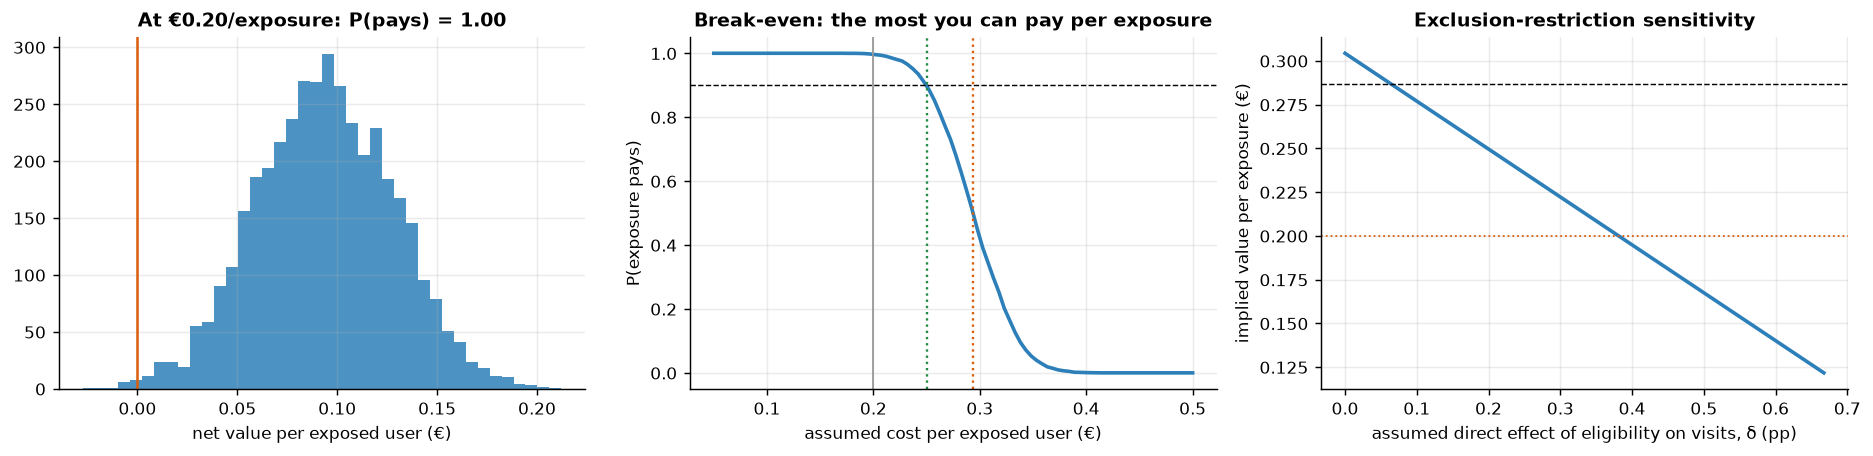

In [10]:
value_post = VALUE_PER_VISIT * iv_post                  # € per exposed user
net = value_post - COST; p_worth = float((net > 0).mean())
costs = np.linspace(0.05, 0.50, 90)
p_pays = np.array([(value_post > c).mean() for c in costs])
c90 = float(np.quantile(value_post, 0.10)); c50 = float(np.median(value_post))
deltas = np.linspace(0, reduced * 0.6, 25)
corrected = VALUE_PER_VISIT * (reduced - deltas) / first

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.6))
ax[0].hist(net, bins=40, color=plots.BLUE, alpha=0.85); ax[0].axvline(0, color=plots.ORANGE, lw=1.4)
ax[0].set_xlabel("net value per exposed user (€)"); ax[0].set_title(f"At €{COST:.2f}/exposure: P(pays) = {p_worth:.2f}")
ax[1].plot(costs, p_pays, color=plots.BLUE, lw=2)
ax[1].axhline(0.9, color="k", ls="--", lw=0.8); ax[1].axvline(c90, color=plots.GREEN, ls=":", lw=1.3)
ax[1].axvline(c50, color=plots.ORANGE, ls=":", lw=1.3); ax[1].axvline(COST, color=plots.GREY, lw=1)
ax[1].set_xlabel("assumed cost per exposed user (€)"); ax[1].set_ylabel("P(exposure pays)")
ax[1].set_title("Break-even: the most you can pay per exposure")
ax[2].plot(100 * deltas, corrected, color=plots.BLUE, lw=2)
ax[2].axhline(COST, color=plots.ORANGE, ls=":", lw=1)
ax[2].axhline(VALUE_PER_VISIT * anchor["visit"]["wald_late"], color="k", ls="--", lw=0.8)
ax[2].set_xlabel("assumed direct effect of eligibility on visits, δ (pp)")
ax[2].set_ylabel("implied value per exposure (€)"); ax[2].set_title("Exclusion-restriction sensitivity")
fig.tight_layout()

break_delta = float(deltas[np.argmax(corrected < COST)]) if np.any(corrected < COST) else np.nan
delta_star = reduced - COST * first / VALUE_PER_VISIT      # closed-form flip threshold (§6 math)
w_conv = anchor["conversion"]["wald_late"]
# secondary rung with uncertainty: subsample Wald for conversion, same delta-method shortcut as the folds
cv = df["conversion"].values
itt_c = cv[z == 1].mean() - cv[z == 0].mean()
se_itt_c = np.sqrt(cv[z == 1].var() / (z == 1).sum() + cv[z == 0].var() / (z == 0).sum())
wald_c, se_c = itt_c / first, se_itt_c / first
lo_c, hi_c = wald_c - 1.645 * se_c, wald_c + 1.645 * se_c
print(f"at €{COST:.2f}/exposed user and €{VALUE_PER_VISIT:.2f}/visit: net €{net.mean():+.2f}, "
      f"P(pays) = {p_worth:.2f}\n"
      f"  -> {'BUY (to the exposed margin)' if p_worth >= 0.9 else 'HOLD'}")
a_w = anchor["visit"]["wald_late"]
print(f"budget cap: clears the 90% bar up to €{c90:.2f}/exposed user; a coin flip at €{c50:.2f}\n"
      f"  — the naive number would have set the cap at €{VALUE_PER_VISIT * naive:.2f} against the\n"
      f"  anchor's causal €{VALUE_PER_VISIT * a_w:.2f}: {100 * (naive - a_w) / a_w:.0f}% too high")
print(f"conversion framing (secondary): full-data anchor LATE {100 * w_conv:+.2f} pp\n"
      f"  -> at €40 margin/conversion an exposure is worth ~€{40 * w_conv:.2f}; the subsample\n"
      f"  pins it only to {100 * wald_c:+.2f} pp (90% CI [{100 * lo_c:+.2f}, {100 * hi_c:+.2f}] pp\n"
      f"  -> €{40 * lo_c:+.2f} to €{40 * hi_c:+.2f}) — at a 0.29% base rate this rung is honestly\n"
      f"  noisy; re-derive with the firm's own margin")
print(f"exclusion stress: the BUY at €{COST:.2f} survives until eligibility's direct effect\n"
      f"  exceeds δ ≈ {100 * break_delta:.2f} pp — {break_delta / reduced:.0%} of the whole reduced form "
      f"({100 * reduced:+.2f} pp)\n"
      f"  would have to bypass exposure")
print(f"  closed form agrees: delta* = ITT - c·π/v = {100 * delta_star:.2f} pp (grid scan: "
      f"{100 * break_delta:.2f} pp)")
premium = VALUE_PER_VISIT * (naive - anchor["visit"]["wald_late"])   # this sample's naive cap vs the causal anchor
premium_full = VALUE_PER_VISIT * (anchor["visit"]["naive"] - anchor["visit"]["wald_late"])   # full-file, the memo's figures
print(f"campaign scale: the naive cap embeds €{premium:.2f}/exposure of pure targeting premium\n"
      f"  (naive €{VALUE_PER_VISIT * naive:.2f} vs causal anchor €{VALUE_PER_VISIT * anchor['visit']['wald_late']:.2f}); "
      f"at {N_EXP_QUARTER:,} exposures/quarter\n"
      f"  that is ≈ €{premium * N_EXP_QUARTER:,.0f}/quarter paid for intent the users already had")
print(f"  full-file version (the CMO memo's numbers): naive cap €{VALUE_PER_VISIT * anchor['visit']['naive']:.2f} "
      f"vs causal €{VALUE_PER_VISIT * anchor['visit']['wald_late']:.2f} —> €{premium_full:.2f}/exposure premium, "
      f"≈ €{premium_full * N_EXP_QUARTER:,.0f}/quarter")

**Read-out — the three panels, then the sentence for the CMO.** *Left*: the net-value posterior
$v\beta - c$ at the assumed €0.20 cost; the printed P(pays) is its mass above the orange zero
line, and the BUY/HOLD call is just whether that mass clears 0.9. *Middle*: the sweep is the
posterior's quantile function in euros (§6's $c^{*} = v\,q_{0.10}(\beta)$) — where the curve
crosses the dashed 0.9 line is the green budget cap, the orange dotted line is the coin-flip
price $v\,q_{0.50}(\beta)$, and the grey line marks today's assumed cost. *Right*: exclusion
stress — the implied value falls linearly as the assumed leak $\delta$ grows (§6's
$\beta(\delta) = (\text{ITT}-\delta)/\pi$); the printed $\delta^{*}$ is where the line crosses
the orange cost line, and the dashed reference is the anchor's ≈€0.29.

**What you would tell the CMO.** "An exposure to the users this auction actually reaches is
worth about €0.29 in expected incremental visits (13.98M-row anchor: +28.7 pp at our assumed
€1/visit); cap bids at the printed 90%-**probability** cap (a posterior quantile — the classical arm
has no such number to give, §5x), a few cents below that. The attribution
dashboard prices the same exposure at ≈ €0.38 (full-file naive gap: +37.9 pp) — about a **quarter** of
that is intent we already owned, so a dashboard-calibrated cap overpays on *every* exposure:
≈ €0.09 each, order of €90k per quarter at a million exposures a quarter (the print above
re-computes this at this run's numbers). Three scope lines before this goes into a rate card:
it is the ATT of the ~3.6% of users the auction actually reaches — it prices *these* exposures
and does not license doubling reach, because the next users the auction would find are, by its
own logic, worse prospects; the €1 visit-value and €40 margin are swept assumptions, so finance
should re-derive the cap with its own numbers; and the BUY survives an eligibility side-channel
only up to the printed $\delta^{*}$ — a leak bigger than that flips the call."

## 7 · Caveats

- **ATT of the exposed, not everyone.** One-sided noncompliance makes monotonicity free, but the
  estimate speaks only for the ~3.6% of users the auction actually reached — the right population
  for "what is an exposure worth," the wrong one for "what if we doubled reach" (the next users the
  auction would reach are, by its own logic, worse prospects).
- **Exclusion is the load-bearing untestable.** The lockout is silent, but any eligibility side
  channel (auction dynamics on other campaigns, mislabelled below-the-fold "exposures") leaks into
  the estimate; step 6 priced the leak that would flip the call.
- **Linear-probability approximation** — binary outcome and binary exposure in a Gaussian joint
  model, as in nb11: read the point and ρ, not the equation-level posterior widths.
- **Visits ≠ profit.** The €1/visit and €40 margin/conversion are finance inputs, swept but
  assumed; the conversion-based rung is noisier (0.29% base rate) and its cap should be re-derived
  at decision time with the firm's own margin.
- **A composite of several tests** — Criteo assembled multiple incrementality tests; the LATE is a
  blend across campaigns/periods (fine for a benchmark cap, blur it into one campaign's plan with care).
- **Subsampling is disclosed, not hidden**: every number above is grade-able against the full-file
  anchor, and the fold check shows exactly how much noise a 200k-row view carries.

**Cite the data:** Diemert, Betlei, Renaudin & Amini (2018), *A Large Scale Benchmark for Uplift
Modeling*, AdKDD. Dataset: Criteo AI Lab, research use.

## Book export

In [11]:
# ---------------------------------------------------------------- Book export (cmp.report)
# Section 13.10 of the book never retypes a number: every figure in its prose is emitted HERE,
# from this executed run, into book/build/results/nb11b.json -> macros.tex. A missing macro is a
# LaTeX compile error, never a silent hole. Figures are re-rendered in book style (vector PDF, no
# in-figure title — the caption does that work) and closed immediately, so this cell changes
# nothing the notebook shows above.
import matplotlib as mpl
from cmp import report as R

# Retire this notebook's OLD keys before writing the new ones. Without this the shard is
# read-modify-written, so a key we stop emitting keeps its macro (and its table file)
# forever — the one way a stale number could survive the injection pipeline.
R.begin("nb11b")

def V(k, v, **kw):
    return R.value(f"nb11b.{k}", v, **kw)

a_w = anchor["visit"]["wald_late"]
a_naive = anchor["visit"]["naive"]
a_itt = anchor["visit"]["itt"]
a_pi = anchor["first_stage"]
w_conv = anchor["conversion"]["wald_late"]

# --- the dataset, and what replaces the planted truth ----------------------------------
V("n_full", int(anchor["n"]), fmt=",d")
V("n_full_m", float(anchor["n"]) / 1e6, fmt=".2f")
V("n_sub", int(len(df)), fmt=",d")
V("n_fit", int(len(df_fit)), fmt=",d")
V("n_arm", int(N_ARM), fmt=",d")
V("p_exposed_eligible", 100 * float(d[z == 1].mean()), fmt=".2f")
V("p_exposed_locked", 100 * float(d[z == 0].mean()), fmt=".2f")
V("base_visit", 100 * float(anchor["visit"]["base_control"]), fmt=".1f")
V("base_conv", 100 * float(anchor["conversion"]["base_control"]), fmt=".2f")
V("f_stat", float(Fstat), fmt=",.0f")
V("f_over_bar", float(Fstat) / 10, fmt=",.0f")
V("f_leak", 100 * float(abs(naive - a_w) / iv2.extra["first_stage_F"]), fmt=".4f")

# --- the anchor (design-based, on all 13.98M rows) -------------------------------------
V("anchor_itt", 100 * float(a_itt), fmt="+.2f")
V("anchor_first", float(a_pi), fmt=".4f")
V("anchor_wald", 100 * float(a_w), fmt="+.2f")
V("anchor_naive", 100 * float(a_naive), fmt="+.2f")
V("anchor_conv_wald", 100 * float(w_conv), fmt="+.2f")
V("anchor_wedge", 100 * float(a_naive - a_w), fmt="+.1f")
V("anchor_wedge_share", 100 * float((a_naive - a_w) / a_naive), fmt=".0f")
V("anchor_inflation", 100 * float((a_naive - a_w) / a_w), fmt="+.0f")
V("dilution_factor", float(1 / first), fmt=",.0f")

# --- the confounding, photographed -----------------------------------------------------
V("smd_z_max", float(np.nanmax(np.abs(smd_z))), fmt=".3f")
V("smd_d_max", float(np.nanmax(np.abs(smd_d))), fmt=".2f")

# --- Step 0 · the classical arm on the working subsample --------------------------------
V("naive", 100 * float(naive), fmt="+.2f")
V("naive_se", 100 * float(ols_naive.se), fmt=".2f")
V("naive_lo", 100 * float(ols_naive.ci[0]), fmt="+.1f")
V("naive_hi", 100 * float(ols_naive.ci[1]), fmt="+.1f")
V("naive_err", 100 * float(naive - a_w), fmt="+.2f")
V("first", float(first), fmt=".4f")
V("first_pct", 100 * float(first), fmt=".2f")
V("reduced", 100 * float(reduced), fmt="+.2f")
V("wald", 100 * float(wald), fmt="+.2f")
V("wald_lo", 100 * float(wald_lo), fmt="+.2f")
V("wald_hi", 100 * float(wald_hi), fmt="+.2f")
V("wald_err", 100 * float(wald - a_w), fmt="+.2f")
V("se_delta", 100 * float(se_delta), fmt=".3f")
V("se_short", 100 * float(se_short), fmt=".3f")
V("se_twosls", 100 * float(iv2.se), fmt=".3f")
V("se_short_gap", 100 * float((se_short - se_delta) / se_delta), fmt="+.1f")
V("se_twosls_ratio", float(iv2.se / se_delta), fmt=".4f")
V("wedge_sub", 100 * float(naive - wald), fmt=".1f")
V("wedge_sub_share", 100 * float((naive - wald) / naive), fmt=".0f")
# The working subsample takes equal rows from each randomized arm (§2). ITT, first stage and the
# Wald all condition on `treatment` and are invariant to that; the naive as-treated gap is the ONE
# estimator it shifts, because its unexposed pool mixes the arms. §2 prices the shift from the
# anchor — emit it, so the chapter can disclose the sampling scheme instead of leaving the gap
# between the subsample naive and the full-file naive unexplained.
V("naive_bal_shift", 100 * float(_naive_bal - a_naive), fmt="+.2f")

# --- §4 · the Bayesian arm --------------------------------------------------------------
_conv = est.convergence_report(iv_idata)
V("bayes_mean", 100 * float(iv_post.mean()), fmt="+.2f")
V("bayes_lo", 100 * float(np.quantile(iv_post, 0.05)), fmt="+.2f")
V("bayes_hi", 100 * float(np.quantile(iv_post, 0.95)), fmt="+.2f")
V("bayes_sd", 100 * float(iv_post.std()), fmt=".2f")
V("n_draws", int(iv_post.size), fmt=",d")
V("rhat", float(_conv["max_rhat"]), fmt=".3f")
V("ess", float(_conv["min_ess_bulk"]), fmt=",.0f")
V("divergences", int(_conv["n_divergences"]), fmt="d")
if _rho is None or not np.isfinite(np.atleast_1d(_rho)).any():
    raise RuntimeError("nb11b book export: endogeneity rho extraction failed (see §4's guarded cell) — "
                       "the book requires nb11b.rho / rho_lo / rho_hi, and a missing macro is a LaTeX "
                       "build failure by policy. Fix the extraction, then re-run this cell.")
V("rho", float(_rho.mean()), fmt="+.2f")
V("rho_lo", float(np.quantile(_rho, 0.05)), fmt="+.2f")
V("rho_hi", float(np.quantile(_rho, 0.95)), fmt="+.2f")

# --- §5 · disjoint-fold stability -------------------------------------------------------
V("n_folds", int(K), fmt="d")
V("fold_rows", int(len(folds[0])), fmt=",d")
V("fold_mean", 100 * float(folds_df.wald.mean()), fmt="+.1f")
V("fold_sd", 100 * float(folds_df.wald.std()), fmt=".1f")
V("fold_cover", 100 * float(cover), fmt=".0f")

# --- §5x · point estimate versus posterior, on the SAME rows ----------------------------
_ew, _eb = abs(_w_f - a_w), abs(iv_post.mean() - a_w)
_hw, _hb = _se_f * 1.645, (_bhi - _blo) / 2
V("fit_naive", 100 * float(_naive_fit.estimate), fmt="+.2f")
V("fit_naive_lo", 100 * float(_naive_fit.ci[0]), fmt="+.2f")
V("fit_naive_hi", 100 * float(_naive_fit.ci[1]), fmt="+.2f")
V("fit_naive_se", 100 * float(_naive_fit.se), fmt=".2f")
V("fit_naive_err", 100 * float(abs(_naive_fit.estimate - a_w)), fmt=".2f")
V("fit_wald", 100 * float(_w_f), fmt="+.2f")
V("fit_wald_lo", 100 * float(_w_f - 1.645 * _se_f), fmt="+.2f")
V("fit_wald_hi", 100 * float(_w_f + 1.645 * _se_f), fmt="+.2f")
V("fit_wald_se", 100 * float(_se_f), fmt=".2f")
V("fit_wald_err", 100 * float(_ew), fmt=".2f")
V("post_err", 100 * float(_eb), fmt=".2f")
V("agree_pp", 100 * float(abs(_w_f - iv_post.mean())), fmt=".2f")
V("agree_ses", float(abs(_w_f - iv_post.mean()) / _se_f), fmt=".2f")
V("err_gap_ses", float(abs(_ew - _eb) / _se_f), fmt=".2f")
V("half_classical", 100 * float(_hw), fmt=".2f")
V("half_bayes", 100 * float(_hb), fmt=".2f")
V("width_ratio", float(_hb / _hw), fmt=".2f")
V("closer", "2SLS (classical)" if _ew < _eb else "the Bayesian posterior")

# --- §6 · the euro decision -------------------------------------------------------------
V("cost", float(COST), unit="EUR", fmt=".2f")
V("value_per_visit", float(VALUE_PER_VISIT), unit="EUR", fmt=".2f")
V("p_pays", float(p_worth), fmt=".2f")
V("net", float(net.mean()), unit="EUR", fmt="+.2f")
V("cap", float(c90), unit="EUR", fmt=".2f")
V("coinflip", float(c50), unit="EUR", fmt=".2f")
V("naive_cap", float(VALUE_PER_VISIT * naive), unit="EUR", fmt=".2f")
V("anchor_cap", float(VALUE_PER_VISIT * a_w), unit="EUR", fmt=".2f")
V("full_naive_cap", float(VALUE_PER_VISIT * a_naive), unit="EUR", fmt=".2f")
V("break_delta", 100 * float(break_delta), fmt=".2f")
V("delta_star", 100 * float(delta_star), fmt=".2f")
V("break_delta_pct", 100 * float(break_delta / reduced), fmt=".0f")
V("premium", float(premium_full), unit="EUR", fmt=".2f")
V("premium_quarter", float(premium_full * N_EXP_QUARTER), unit="EUR", fmt=",.0f")
V("exposures_quarter", int(N_EXP_QUARTER), fmt=",d")
V("conv_margin", 40, unit="EUR", fmt=".0f")
V("conv_value", float(40 * w_conv), unit="EUR", fmt=".2f")
V("p_at_cost", float((VALUE_PER_VISIT * iv_post > 0.20).mean()), fmt=".2f")
V("p_at_anchor", float((VALUE_PER_VISIT * iv_post > 0.28).mean()), fmt=".2f")
V("p_at_naive", float((VALUE_PER_VISIT * iv_post > 0.32).mean()), fmt=".2f")

# --- tables (cells plain text — report.table escapes them; only headers may carry math) --
R.table(pd.DataFrame([
    {"Rung": "(1) naive as-treated [BIASED]", "Est. (pp)": f"{100 * naive:+.2f}",
     "SE (pp)": f"{100 * ols_naive.se:.2f}",
     "90% CI (pp)": f"[{100 * ols_naive.ci[0]:+.1f}, {100 * ols_naive.ci[1]:+.1f}]",
     "Anchor in?": ("yes" if ols_naive.ci[0] <= a_w <= ols_naive.ci[1] else "NO")},
    {"Rung": "(2) first stage, X on Z", "Est. (pp)": f"{100 * first:.2f}",
     "SE (pp)": f"{100 * first_st.se:.3f}",
     "90% CI (pp)": f"[{100 * first_st.ci[0]:.2f}, {100 * first_st.ci[1]:.2f}]",
     "Anchor in?": "—"},
    {"Rung": "(3) reduced form = ITT", "Est. (pp)": f"{100 * reduced:+.2f}",
     "SE (pp)": f"{100 * red_form.se:.3f}",
     "90% CI (pp)": f"[{100 * red_form.ci[0]:+.2f}, {100 * red_form.ci[1]:+.2f}]",
     "Anchor in?": ("yes" if red_form.ci[0] <= a_itt <= red_form.ci[1] else "NO")},
    {"Rung": "(4) ratio (3)/(2) = 2SLS: ATT", "Est. (pp)": f"{100 * wald:+.2f}",
     "SE (pp)": f"{100 * se_delta:.2f}",
     "90% CI (pp)": f"[{100 * wald_lo:+.1f}, {100 * wald_hi:+.1f}]",
     "Anchor in?": ("yes" if wald_lo <= a_w <= wald_hi else "NO")},
]), "nb11b.rungs", align="lrrcc",
    caption=(f"Applied IV on {len(df):,} rows of the Criteo experiment, graded against the "
             f"design-based anchor computed on all {anchor['n']:,} rows "
             f"({100 * a_w:+.2f} pp for the Wald, {100 * a_itt:+.2f} pp for the ITT). Row (1) is the "
             f"attribution dashboard's number and it carries the \\emph{{tightest}} interval in the "
             f"section (SE {100 * ols_naive.se:.2f} pp) around a number "
             f"{100 * (naive - a_w):+.1f} pp from the anchor --- an anchor its own interval excludes. "
             f"Row (3) is honest and useless alone: unbiased for the \\emph{{intent}}, but diluted by "
             f"the compliance rate by a factor of $1/\\hat\\pi \\approx {1 / first:,.0f}$. Only their "
             f"ratio is denominated in the unit a bid is priced in. Standard errors are HC1 for rows "
             f"(1)--(3) and the delta method for row (4)."),
    label="tab:iv:realrungs")

R.table(pd.DataFrame([
    {"Estimator (pp / exposure)": "naive as-treated [BIASED]",
     "Est.": f"{100 * _naive_fit.estimate:+.2f}", "5%": f"{100 * _naive_fit.ci[0]:+.2f}",
     "95%": f"{100 * _naive_fit.ci[1]:+.2f}", "|err|": f"{100 * abs(_naive_fit.estimate - a_w):.2f}",
     "covers": ("yes" if _naive_fit.ci[0] <= a_w <= _naive_fit.ci[1] else "NO"), "P(pays, €0.28)": "not defined"},
    {"Estimator (pp / exposure)": "Wald = 2SLS (delta)", "Est.": f"{100 * _w_f:+.2f}",
     "5%": f"{100 * (_w_f - 1.645 * _se_f):+.2f}", "95%": f"{100 * (_w_f + 1.645 * _se_f):+.2f}",
     "|err|": f"{100 * _ew:.2f}",
     "covers": ("yes" if (_w_f - 1.645 * _se_f) <= a_w <= (_w_f + 1.645 * _se_f) else "NO"), "P(pays, €0.28)": "not defined"},
    {"Estimator (pp / exposure)": "Bayesian IV posterior", "Est.": f"{100 * iv_post.mean():+.2f}",
     "5%": f"{100 * _blo:+.2f}", "95%": f"{100 * _bhi:+.2f}", "|err|": f"{100 * _eb:.2f}",
     "covers": ("yes" if _blo <= a_w <= _bhi else "NO"), "P(pays, €0.28)": f"{(VALUE_PER_VISIT * iv_post > 0.28).mean():.2f}"},
]), "nb11b.compare", align="lrrrrcc",
    caption=(f"Bernstein--von Mises in a print-out. The same estimand (the ATT of the exposed), the "
             f"same assumptions, the same {len(df_fit):,} rows --- the classical arm is re-run on "
             f"exactly the slice the sampler saw, so the comparison is apparatus against apparatus "
             f"and not $n$ against $n$. The referee is the {anchor['n']:,}-row anchor, "
             f"{100 * a_w:+.2f} pp. The two causal rows agree to {100 * abs(_w_f - iv_post.mean()):.2f} "
             f"pp --- {abs(_w_f - iv_post.mean()) / _se_f:.2f} classical standard errors --- and their "
             f"interval widths differ by {100 * abs(1 - _hb / _hw):.0f}\\,\\%. 2SLS is nominally the closer of "
             f"two to the anchor, by {abs(_ew - _eb) / _se_f:.2f} standard errors: that is noise, not "
             f"skill, and this section declines to call a winner. The naive row is the only one that "
             f"is decisively wrong, and it carries the tightest interval."),
    label="tab:iv:realcompare")

# --- figures ----------------------------------------------------------------------------
with mpl.rc_context(R.book_style()):
    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    _yp = np.arange(len(feats))
    a.scatter(smd_z, _yp, color=plots.GREEN, s=30, label="across eligibility (randomized)")
    a.scatter(smd_d, _yp, color=plots.ORANGE, s=30, label="across exposure (self-selected)")
    a.axvline(0, color="k", lw=0.7)
    a.axvline(0.1, color=plots.GREY, ls=":", lw=0.8); a.axvline(-0.1, color=plots.GREY, ls=":", lw=0.8)
    a.set_yticks(_yp); a.set_yticklabels(feats)
    a.set_xlabel("standardized mean difference")
    a.legend(frameon=False, fontsize=8.5)
    f.tight_layout()
    R.figure(f, "nb11b.smd", caption=(
        f"The confounding, photographed --- the one thing a simulator can never show. Each row is one "
        f"of the twelve anonymized user features. In green, its standardized mean difference across "
        f"the \\emph{{randomized}} eligibility flag: flat, with a maximum of "
        f"{np.nanmax(np.abs(smd_z)):.3f}, which is the instrument's exogeneity, audited. In orange, "
        f"the same difference across \\emph{{actual exposure}}: as large as "
        f"{np.nanmax(np.abs(smd_d)):.2f} standard deviations. The users the auction chose to expose "
        f"were different people \\emph{{before any ad ran}} --- the unobserved intent of "
        f"\\cref{{eq:iv:dgp}}, measured. And this is only its observable shadow: the auction also bid "
        f"on signals that are not in the file, which is exactly the case in which covariate "
        f"adjustment surrenders and an instrument is required."),
        label="fig:iv:smd")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 3.0)); a2 = f.subplots(1, 2)
    a2[0].hist(100 * iv_post, bins=40, color=plots.BLUE, alpha=0.85,
               label=f"posterior ({len(df_fit):,} rows)")
    a2[0].axvline(100 * a_w, color="k", ls="--", lw=1.4, label=f"anchor {100 * a_w:+.1f} pp")
    a2[0].axvline(100 * naive, color=plots.ORANGE, lw=1.6, label=f"naive {100 * naive:+.1f} pp")
    a2[0].axvline(100 * wald, color=plots.GOLD, ls=":", lw=1.4, label=f"Wald {100 * wald:+.1f} pp")
    a2[0].set_xlabel("exposure → visit effect (pp)"); a2[0].set_ylabel("posterior draws")
    a2[0].legend(frameon=False, fontsize=8)
    a2[1].bar(["locked out", "eligible"], [d[z == 0].mean(), d[z == 1].mean()],
              color=[plots.GREY, plots.GREEN], alpha=0.9)
    a2[1].set_ylabel("P(exposed)")
    f.tight_layout()
    R.figure(f, "nb11b.anchor", caption=(
        f"\\emph{{Left}}: the same four markers as \\cref{{fig:iv:bias}}, now with no planted truth. "
        f"The orange line is the attribution dashboard ({100 * naive:+.1f} pp); the dashed black line "
        f"is the design-based anchor computed on all {anchor['n']:,} rows ({100 * a_w:+.1f} pp); gold "
        f"is this subsample's Wald ratio and blue the posterior. The horizontal distance from orange "
        f"to black \\emph{{is}} the self-selection premium, measured rather than simulated: on the "
        f"full file {100 * (a_naive - a_w):.1f} pp of the {100 * a_naive:.1f} pp dashboard number --- "
        f"{100 * (a_naive - a_w) / a_naive:.0f}\\,\\% of it --- was intent the exposed users already "
        f"had. \\emph{{Right}}: the first stage is the design itself, not a diagnostic that happened "
        f"to pass. The locked-out bar is \\emph{{exactly}} zero (one-sided noncompliance, which is "
        f"what turns the LATE into the ATT), and the eligible bar --- "
        f"{100 * d[z == 1].mean():.1f}\\,\\% --- is the entire lever the instrument pulls. "
        f"$F = {Fstat:,.0f}$ is the licence to divide by it."),
        label="fig:iv:anchor")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 2.9)); a = f.add_subplot(111)
    a.errorbar(np.arange(K), 100 * folds_df.wald, yerr=100 * (folds_df.wald - folds_df.lo),
               fmt="o", color=plots.BLUE, ms=5, capsize=3)
    a.axhline(100 * a_w, color="k", ls="--", lw=1)
    a.text(K - 0.6, 100 * a_w + 0.8, "anchor", fontsize=8.5)
    a.set_xlabel(f"disjoint fold ({len(folds[0]):,} rows each)")
    a.set_ylabel("Wald LATE (pp)")
    f.tight_layout()
    R.figure(f, "nb11b.folds", caption=(
        f"Fresh samples, without a simulator. Multi-seed recovery cannot be run on real data --- there "
        f"is only one world --- but {anchor['n'] / 1e6:.2f} million rows afford fresh \\emph{{samples}}: "
        f"the working subsample is cut into {K} disjoint folds of {len(folds[0]):,} rows and the same "
        f"estimator refit on each, with the delta-method interval recomputed per fold. The fold Walds "
        f"average {100 * folds_df.wald.mean():+.1f} pp with a standard deviation of "
        f"{100 * folds_df.wald.std():.1f} pp around the {100 * a_w:+.1f} pp anchor, and their 90\\,\\% "
        f"intervals cover it in {100 * cover:.0f}\\,\\% of folds. That spread is the honest price of "
        f"3.6\\,\\% exposure rate --- and the reason the anchor is computed on the whole file rather "
        f"than a slice of it."),
        label="fig:iv:folds")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 2.5)); a3 = f.subplots(1, 3)
    a3[0].hist(net, bins=40, color=plots.BLUE, alpha=0.85)
    a3[0].axvline(0, color=plots.ORANGE, lw=1.4)
    a3[0].set_xlabel("net value / exposed user (€)"); a3[0].set_ylabel("draws")
    a3[1].plot(costs, p_pays, color=plots.BLUE, lw=2)
    a3[1].axhline(0.9, color="k", ls="--", lw=0.8)
    a3[1].axvline(c90, color=plots.GREEN, ls=":", lw=1.3)
    a3[1].axvline(c50, color=plots.ORANGE, ls=":", lw=1.3)
    a3[1].axvline(COST, color=plots.GREY, lw=1)
    a3[1].set_xlabel("assumed cost / exposure (€)"); a3[1].set_ylabel("P(exposure pays)")
    a3[2].plot(100 * deltas, corrected, color=plots.BLUE, lw=2)
    a3[2].axhline(COST, color=plots.ORANGE, ls=":", lw=1)
    a3[2].axhline(VALUE_PER_VISIT * a_w, color="k", ls="--", lw=0.8)
    a3[2].set_xlabel("assumed direct effect δ (pp)")
    a3[2].set_ylabel("implied value / exposure (€)")
    f.tight_layout()
    R.figure(f, "nb11b.euro", caption=(
        f"The euro decision on real data. \\emph{{Left}}: the posterior of net value per exposed user "
        f"at the assumed \\texteuro{COST:.2f} cost and \\texteuro{VALUE_PER_VISIT:.2f} per "
        f"incremental visit; its mass above zero is $\\Prob(\\text{{pays}}) = {p_worth:.2f}$. "
        f"\\emph{{Middle}}: the sweep is the posterior's quantile function denominated in euros. Where "
        f"it crosses the 0.9 bar is the bid cap, \\texteuro{c90:.2f} per exposed user --- a "
        f"\\textbf{{90\\,\\% probability bar}}, not a confidence bar, and therefore a number no "
        f"classical interval in this chapter can produce. The coin-flip price is "
        f"\\texteuro{c50:.2f}. \\emph{{Right}}: the exclusion restriction, priced. The buy call "
        f"survives an eligibility side-channel of up to $\\delta \\approx {100 * break_delta:.2f}$ pp "
        f"--- {100 * break_delta / reduced:.0f}\\,\\% of the entire {100 * reduced:+.2f} pp reduced "
        f"form would have to bypass exposure to overturn it."),
        label="fig:iv:realeuro")
    plt.close(f)


# --- §5z · the link-function check: the probit refit, graded against the anchor ----------
V("probit_est", 100 * float(probit_est), fmt="+.2f")
V("probit_lo", 100 * float(probit_lo), fmt="+.2f")
V("probit_hi", 100 * float(probit_hi), fmt="+.2f")
V("probit_gap", 100 * float(probit_gap), fmt="+.2f")          # probit's distance from the anchor
V("lpm_gap", 100 * float(lpm_gap), fmt="+.2f")                # the shipped LPM's distance from it
V("probit_verdict", probit_verdict)
V("probit_rho", float(rho_probit.mean()), fmt="+.3f")
V("probit_rho_hi", float(np.quantile(rho_probit, 0.95)), fmt="+.3f")
V("probit_naive_dist", 100 * float(abs(probit_est - _naive_fit.estimate)), fmt=".2f")
V("probit_width_ratio", float((lpm_hi - lpm_lo) / (probit_hi - probit_lo)), fmt=".1f")

R.table(pd.DataFrame([
    {"First stage": "linear probability (CausalPy, shipped)", "Est. (pp)": f"{100 * lpm_est:+.2f}",
     "90\\,\\% interval (pp)": f"[{100 * lpm_lo:+.2f}, {100 * lpm_hi:+.2f}]",
     "Distance from anchor (pp)": f"{100 * lpm_gap:+.2f}"},
    {"First stage": "probit (nb11's repair, refit on the same rows)",
     "Est. (pp)": f"{100 * probit_est:+.2f}",
     "90\\,\\% interval (pp)": f"[{100 * probit_lo:+.2f}, {100 * probit_hi:+.2f}]",
     "Distance from anchor (pp)": f"{100 * probit_gap:+.2f}"},
    {"First stage": f"Wald anchor ({anchor['n']:,} rows, design-based)",
     "Est. (pp)": f"{100 * a_w:+.2f}", "90\\,\\% interval (pp)": "--",
     "Distance from anchor (pp)": "0 (by definition)"},
]), "nb11b.probit", align="lrrr", math_headers=True,
    caption=(f"The one claim in this chapter that was asserted rather than measured, now measured. "
             f"CausalPy's joint MvNormal makes the binary first stage a \\emph{{linear-probability}} "
             f"equation; the simulated twin repaired exactly that with a probit and was "
             f"rewarded for it. Refit on the same {len(df_fit):,} rows and graded against the "
             f"{anchor['n']:,}-row anchor, the repair \\emph{{fails}}: the probit lands "
             f"{100 * abs(probit_gap):.1f} pp from the anchor --- within "
             f"{100 * abs(probit_est - _naive_fit.estimate):.2f} pp of the naive as-treated gap it was "
             f"supposed to correct --- and reports "
             f"$\\rho = {rho_probit.mean():+.3f}$, i.e.\\ no endogeneity at all. Its interval is "
             f"{(lpm_hi - lpm_lo) / (probit_hi - probit_lo):.1f}$\\times$ \\emph{{tighter}} than the "
             f"shipped fit's, around a number ten points wrong. The reason the linear first stage "
             f"survives is not that $n$ drowns its error but that a binary-on-binary first stage is "
             f"\\emph{{saturated}}, so the mean structure the causal $\\beta$ is read off is exact; the "
             f"outcome here is binary too, which leaves the probit's $\\operatorname{{corr}}(u, e)$ --- "
             f"the channel that carried the confounding on nb11's continuous outcome --- nothing to "
             f"grip. A likelihood repair is a repair only relative to a data-generating process."),
    label="tab:iv:realprobit")

print(f"book export: {len([k for k in R.load() if k.startswith('nb11b.')])} keys emitted "
      f"to book/build/results/nb11b.json")


book export: 114 keys emitted to book/build/results/nb11b.json
